# Simulating Autism-Associated Physiological Patterns for Emotion-Adaptive Music Generation

## A Computational Framework


**Abstract:** This notebook implements a computational framework for simulating autism spectrum disorder (ASD)-associated physiological patterns and their effects on emotion-adaptive music generation. Using the DEAP dataset, we extract EEG and EDA features, train an emotion recognition model, simulate ASD-like physiological signatures based on literature, and analyze how these affect predicted emotional states and generated therapeutic music parameters.

---

**Table of Contents:**
1. Setup and Installation
2. DEAP Data Loading
3. Signal Preprocessing
4. Feature Extraction
5. Emotion Recognition Model
6. ASD Physiological Simulation
7. Therapeutic Music Generation
8. Experiments and Results
9. Paper Methods Reference

---
# 1. Setup and Installation
---

## 1.1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# ============================================================
# CONFIGURE THESE PATHS FOR YOUR GOOGLE DRIVE STRUCTURE
# ============================================================

# Base project directory - Make sure this is an absolute path
PROJECT_DIR = os.path.join('/content/drive/MyDrive', "2025/ASD_Project/DEAP_Data")

# DEAP preprocessed data location - Make sure this is also an absolute path
DEAP_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'deap-dataset', 'data_preprocessed_python')

# Output directories
FEATURE_DIR = os.path.join(PROJECT_DIR, 'features')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MIDI_DIR = os.path.join(PROJECT_DIR, 'midi_output')
CACHE_DIR = os.path.join(PROJECT_DIR, 'cache')

# Create directories
# for d in [PROJECT_DIR, FEATURE_DIR, MODEL_DIR, RESULTS_DIR, MIDI_DIR, CACHE_DIR]:
#     os.makedirs(d, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"DEAP data path: {DEAP_DATA_PATH}")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data
DEAP data path: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/data/deap-dataset/data_preprocessed_python


## 1.2 Install Dependencies

In [2]:
# Install required packages
!pip install scipy mne torch torchaudio matplotlib seaborn -q
!pip install mido midiutil pretty_midi pyfluidsynth -q
!pip install neurokit2 antropy scikit-learn pandas -q
!apt-get install -y fluidsynth > /dev/null 2>&1
!pip install midi2audio pydub -q

print("Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 60.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 58.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 15.4 MB/s eta 0:00:00
Installation complete!


## 1.3 Import Libraries

In [3]:
import os
import sys
import time
import pickle
import json
import warnings
import math
import random
from typing import Optional, Tuple, List, Dict
from dataclasses import dataclass, field
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import signal, stats
from scipy.fft import fft, fftfreq
from scipy.signal import welch, find_peaks, coherence, butter, filtfilt, iirnotch
from scipy.ndimage import median_filter

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils import clip_grad_norm_

# Signal Processing
import mne
import neurokit2 as nk

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# ML and Stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Music Generation
import mido
from midiutil import MIDIFile
import pretty_midi

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
Device: cpu


---
# 2. DEAP Data Loading
---

The DEAP dataset contains physiological recordings from 32 participants watching 40 one-minute music videos. Each trial includes:
- 32-channel EEG
- Peripheral physiological signals (including EDA/GSR)
- Self-reported ratings for valence, arousal, dominance, and liking

In [ ]:
class DEAPDataLoader:
    """
    DEAP dataset loader for preprocessed .dat (pickle) files.

    The DEAP dataset structure:
    - 32 participants (s01.dat to s32.dat)
    - 40 trials per participant (40 music videos)
    - 40 channels: 32 EEG + 8 peripheral (EOG, EMG, GSR, Respiration, etc.)
    - 8064 samples per trial (63 seconds at 128 Hz, including 3s baseline)
    - Labels: valence, arousal, dominance, liking (1-9 scale)
    """

    def __init__(self, data_dir=None, cache_dir=CACHE_DIR):
        # Use the global DEAP_DATA_PATH if not explicitly provided
        # Ensure it's treated as relative to /content/drive/MyDrive
        if data_dir is None:
            self.data_dir = os.path.join('/content/drive/MyDrive', DEAP_DATA_PATH.replace('/content/drive/MyDrive/', '')) if not DEAP_DATA_PATH.startswith('/content/drive/MyDrive/') else DEAP_DATA_PATH
        else:
            self.data_dir = os.path.join('/content/drive/MyDrive', data_dir.replace('/content/drive/MyDrive/', '')) if not data_dir.startswith('/content/drive/MyDrive/') else data_dir

        self.cache_dir = cache_dir

        # Sampling parameters
        self.fs = 128  # DEAP preprocessed sampling rate
        self.fs_eeg = 128
        self.fs_eda = 128
        self.trial_duration = 60  # seconds (excluding 3s baseline)
        self.baseline_duration = 3  # seconds

        # Channel configuration
        self.n_eeg_channels = 32
        self.n_total_channels = 40

        # EEG channel names (10-20 system)
        self.eeg_channels = [
            'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
            'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
            'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz',
            'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2'
        ]

        # Peripheral channel indices (after 32 EEG channels)
        self.peripheral_channels = {
            'hEOG': 32,    # Horizontal EOG
            'vEOG': 33,    # Vertical EOG
            'zEMG': 34,    # Zygomaticus EMG
            'tEMG': 35,    # Trapezius EMG
            'GSR': 36,     # Galvanic Skin Response (EDA)
            'Resp': 37,    # Respiration
            'Plet': 38,    # Plethysmograph (BVP)
            'Temp': 39     # Temperature
        }

        # Label names
        self.label_names = ['valence', 'arousal', 'dominance', 'liking']

        os.makedirs(cache_dir, exist_ok=True)

    def load_participant(self, participant_id):
        """
        Load single participant data from .dat file.

        Args:
            participant_id: int, 1-32

        Returns:
            dict with keys: 'eeg', 'eda', 'labels', 'participant_id'
        """
        file_path = os.path.join(self.data_dir, f's{participant_id:02d}.dat')

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"DEAP file not found: {file_path}")

        # Load pickle file
        with open(file_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')

        # Extract data
        # Shape: (40 trials, 40 channels, 8064 samples)
        signals = data['data']
        # Shape: (40 trials, 4 labels) - valence, arousal, dominance, liking
        labels = data['labels']

        # Remove 3-second baseline (384 samples at 128 Hz)
        baseline_samples = self.baseline_duration * self.fs
        signals = signals[:, :, baseline_samples:]

        # Extract modalities
        eeg = signals[:, :self.n_eeg_channels, :]  # (40, 32, 7680)
        eda = signals[:, self.peripheral_channels['GSR'], :]  # (40, 7680)

        # Normalize labels to 0-1 range (original: 1-9)
        labels_normalized = (labels - 1) / 8.0

        return {
            'eeg': eeg,
            'eda': eda,
            'labels': labels_normalized,
            'labels_raw': labels,
            'participant_id': participant_id
        }

    def load_all_participants(self, participant_ids=None):
        """
        Load data from multiple participants.

        Args:
            participant_ids: list of ints, or None for all (1-32)

        Returns:
            dict with combined data and participant indices
        """
        if participant_ids is None:
            participant_ids = range(1, 33)

        all_eeg = []
        all_eda = []
        all_labels = []
        all_pids = []

        for pid in participant_ids:
            try:
                data = self.load_participant(pid)
                all_eeg.append(data['eeg'])
                all_eda.append(data['eda'])
                all_labels.append(data['labels'])
                all_pids.extend([pid] * data['eeg'].shape[0])
                print(f"Loaded participant {pid}")
            except FileNotFoundError as e:
                print(f"Warning: {e}")
                continue

        return {
            'eeg': np.concatenate(all_eeg, axis=0),
            'eda': np.concatenate(all_eda, axis=0),
            'labels': np.concatenate(all_labels, axis=0),
            'participant_ids': np.array(all_pids)
        }

    def get_trial_info(self):
        """Return information about the dataset structure."""
        return {
            'n_participants': 32,
            'n_trials_per_participant': 40,
            'trial_duration_sec': self.trial_duration,
            'sampling_rate': self.fs,
            'n_eeg_channels': self.n_eeg_channels,
            'eeg_channel_names': self.eeg_channels,
            'label_names': self.label_names
        }


# Initialize loader
loader = DEAPDataLoader(data_dir=DEAP_DATA_PATH) # Explicitly pass the current, correct DEAP_DATA_PATH
print("\nDataset Info:")
for k, v in loader.get_trial_info().items():
    print(f"  {k}: {v}")


Dataset Info:
  n_participants: 32
  n_trials_per_participant: 40
  trial_duration_sec: 60
  sampling_rate: 128
  n_eeg_channels: 32
  eeg_channel_names: ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2']
  label_names: ['valence', 'arousal', 'dominance', 'liking']


In [ ]:
import os

path = "/content/drive/MyDrive/Victoria/DEAP_Data"

if os.path.exists(path):
    print("Contents of Victoria folder:")
    for item in os.listdir(path):
        print(item)
else:
    print("Path does not exist:", path)

Contents of Victoria folder:
data
features
models
deap-dataset.zip
DataSet_Links.gdoc
results
midi_output
cache
DEAP_DataUnzip_Check.ipynb
HybridModel.ipynb


In [ ]:
# Test loading a single participant
print("Testing data loading...")
test_data = loader.load_participant(1)

print(f"\nParticipant 1 data shapes:")
print(f"  EEG: {test_data['eeg'].shape} (trials, channels, samples)")
print(f"  EDA: {test_data['eda'].shape} (trials, samples)")
print(f"  Labels: {test_data['labels'].shape} (trials, labels)")
print(f"\nLabel ranges (normalized 0-1):")
print(f"  Valence: {test_data['labels'][:, 0].min():.2f} - {test_data['labels'][:, 0].max():.2f}")
print(f"  Arousal: {test_data['labels'][:, 1].min():.2f} - {test_data['labels'][:, 1].max():.2f}")

Testing data loading...

Participant 1 data shapes:
  EEG: (40, 32, 7680) (trials, channels, samples)
  EDA: (40, 7680) (trials, samples)
  Labels: (40, 4) (trials, labels)

Label ranges (normalized 0-1):
  Valence: -0.12 - 0.91
  Arousal: 0.00 - 0.89


Now that the data is extracted, we need to update the `DEAP_DATA_PATH` variable in the `mount_drive` cell to point to the new directory: `DEAP_Data/data`.

---
# 3. Signal Preprocessing
---

Signal preprocessing for EEG and EDA signals:
- **EEG**: Band-pass filtering (0.5-45 Hz), notch filtering (50/60 Hz)
- **EDA**: Median filtering, low-pass filtering, decomposition into tonic/phasic components

In [ ]:
class SignalPreprocessor:
    """
    Preprocessing pipeline for EEG and EDA signals.
    """

    def __init__(self, fs_eeg=128, fs_eda=128):
        self.fs_eeg = fs_eeg
        self.fs_eda = fs_eda

    # ==================== EEG Preprocessing ====================

    def bandpass_filter(self, data, lowcut, highcut, fs, order=4):
        """Apply Butterworth bandpass filter."""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def notch_filter(self, data, freq, fs, Q=30):
        """Apply notch filter to remove line noise."""
        nyq = 0.5 * fs
        w0 = freq / nyq
        b, a = iirnotch(w0, Q)
        return filtfilt(b, a, data, axis=-1)

    def preprocess_eeg(self, eeg, lowcut=0.5, highcut=45.0):
        """
        Preprocess EEG signals.

        Args:
            eeg: ndarray, shape (channels, samples) or (trials, channels, samples)

        Returns:
            Preprocessed EEG signals
        """
        # Handle both single trial and batch
        single_trial = eeg.ndim == 2
        if single_trial:
            eeg = eeg[np.newaxis, :, :]

        processed = []
        for trial in eeg:
            # Bandpass filter
            trial_filtered = self.bandpass_filter(trial, lowcut, highcut, self.fs_eeg)
            # Notch filter for line noise (50 Hz and 60 Hz)
            trial_filtered = self.notch_filter(trial_filtered, 50, self.fs_eeg)
            trial_filtered = self.notch_filter(trial_filtered, 60, self.fs_eeg)
            processed.append(trial_filtered)

        result = np.array(processed)
        return result[0] if single_trial else result

    # ==================== EDA Preprocessing ====================

    def lowpass_filter(self, data, cutoff, fs, order=4):
        """Apply Butterworth lowpass filter."""
        nyq = 0.5 * fs
        normalized_cutoff = cutoff / nyq
        b, a = butter(order, normalized_cutoff, btype='low')
        return filtfilt(b, a, data)

    def decompose_eda(self, eda):
        """
        Decompose EDA into tonic (SCL) and phasic (SCR) components.

        Args:
            eda: 1D array of EDA signal

        Returns:
            dict with 'tonic', 'phasic', 'filtered' components
        """
        # Median filter for artifact removal
        eda_filtered = median_filter(eda, size=5)

        # Low-pass filter at 1 Hz
        eda_filtered = self.lowpass_filter(eda_filtered, 1.0, self.fs_eda)

        # Tonic component (very low frequency)
        tonic = self.lowpass_filter(eda_filtered, 0.05, self.fs_eda)

        # Phasic component (residual)
        phasic = eda_filtered - tonic

        return {
            'filtered': eda_filtered,
            'tonic': tonic,
            'phasic': phasic
        }

    def preprocess_eda(self, eda):
        """
        Preprocess EDA signals.

        Args:
            eda: ndarray, shape (samples,) or (trials, samples)

        Returns:
            dict with preprocessed components
        """
        single_trial = eda.ndim == 1
        if single_trial:
            eda = eda[np.newaxis, :]

        results = {'filtered': [], 'tonic': [], 'phasic': []}

        for trial in eda:
            decomposed = self.decompose_eda(trial)
            for key in results:
                results[key].append(decomposed[key])

        for key in results:
            results[key] = np.array(results[key])
            if single_trial:
                results[key] = results[key][0]

        return results


# Initialize preprocessor
preprocessor = SignalPreprocessor()
print("SignalPreprocessor initialized")

SignalPreprocessor initialized


EEG processed shape: (32, 7680)
EDA components: ['filtered', 'tonic', 'phasic']


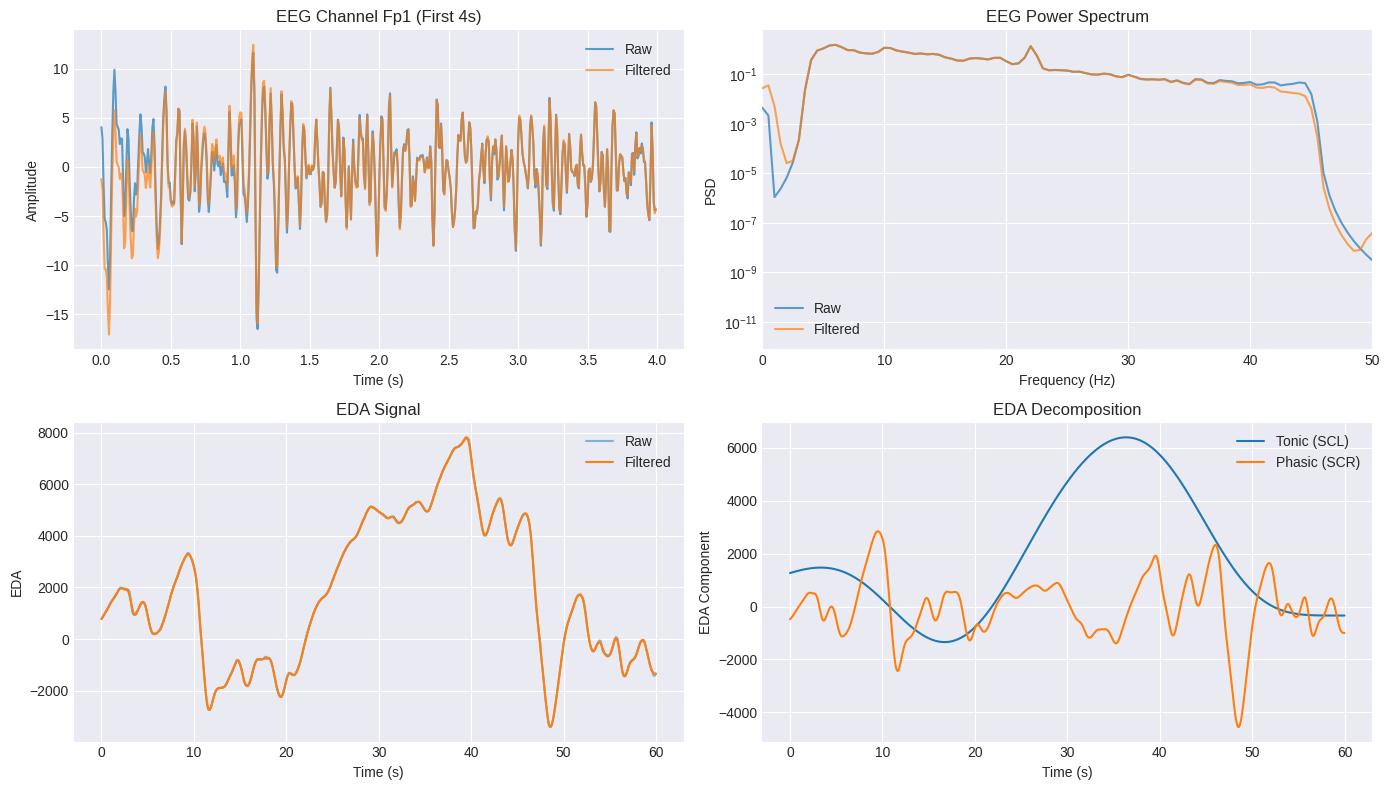

In [ ]:
# Test preprocessing on sample data
sample_eeg = test_data['eeg'][0]  # First trial, shape (32, 7680)
sample_eda = test_data['eda'][0]  # First trial, shape (7680,)

# Preprocess
eeg_processed = preprocessor.preprocess_eeg(sample_eeg)
eda_processed = preprocessor.preprocess_eda(sample_eda)

print(f"EEG processed shape: {eeg_processed.shape}")
print(f"EDA components: {list(eda_processed.keys())}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# EEG before/after
t = np.arange(sample_eeg.shape[1]) / 128
axes[0, 0].plot(t[:512], sample_eeg[0, :512], alpha=0.7, label='Raw')
axes[0, 0].plot(t[:512], eeg_processed[0, :512], alpha=0.7, label='Filtered')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('EEG Channel Fp1 (First 4s)')
axes[0, 0].legend()

# EEG power spectrum
freqs, psd_raw = welch(sample_eeg[0], fs=128, nperseg=256)
freqs, psd_filt = welch(eeg_processed[0], fs=128, nperseg=256)
axes[0, 1].semilogy(freqs, psd_raw, alpha=0.7, label='Raw')
axes[0, 1].semilogy(freqs, psd_filt, alpha=0.7, label='Filtered')
axes[0, 1].set_xlabel('Frequency (Hz)')
axes[0, 1].set_ylabel('PSD')
axes[0, 1].set_title('EEG Power Spectrum')
axes[0, 1].set_xlim([0, 50])
axes[0, 1].legend()

# EDA decomposition
axes[1, 0].plot(t, sample_eda, alpha=0.5, label='Raw')
axes[1, 0].plot(t, eda_processed['filtered'], label='Filtered')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('EDA')
axes[1, 0].set_title('EDA Signal')
axes[1, 0].legend()

# Tonic/Phasic
axes[1, 1].plot(t, eda_processed['tonic'], label='Tonic (SCL)')
axes[1, 1].plot(t, eda_processed['phasic'], label='Phasic (SCR)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('EDA Component')
axes[1, 1].set_title('EDA Decomposition')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/preprocessing_example.png", dpi=150)
plt.show()

---
# 4. Feature Extraction
---

Extract features from EEG and EDA signals using sliding windows:

**EEG Features:**
- Bandpower: Delta (0.5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz), Beta (13-30 Hz), Gamma (30-45 Hz)
- Ratios: Theta/Beta, Alpha/Beta, Attention Index
- Connectivity: Inter-hemispheric coherence (for ASD analysis)

**EDA Features:**
- Tonic: Mean, std, slope, range
- Phasic: SCR count, rate, amplitude
- Statistical: Skewness, kurtosis, IQR

In [ ]:
class FeatureExtractor:
    """
    Extract features from EEG and EDA signals for emotion recognition.
    Includes ASD-relevant features like gamma power and connectivity.
    """

    def __init__(self, fs_eeg=128, fs_eda=128, window_sec=4, overlap=0.5):
        self.fs_eeg = fs_eeg
        self.fs_eda = fs_eda
        self.window_sec = window_sec
        self.overlap = overlap
        self.window_samples_eeg = int(window_sec * fs_eeg)
        self.window_samples_eda = int(window_sec * fs_eda)
        self.step_samples = int(self.window_samples_eeg * (1 - overlap))

        self.preprocessor = SignalPreprocessor(fs_eeg, fs_eda)

        # EEG frequency bands
        self.freq_bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }

        # Channel pairs for connectivity (left-right hemispheres)
        self.connectivity_pairs = [
            ('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'),
            ('P3', 'P4'), ('O1', 'O2'), ('T7', 'T8')
        ]

        # Channel name to index mapping
        self.ch_names = [
            'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
            'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
            'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz',
            'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2'
        ]
        self.ch_idx = {name: i for i, name in enumerate(self.ch_names)}

    # ==================== EEG Features ====================

    def compute_bandpower(self, eeg_segment, band):
        """
        Compute bandpower for a specific frequency band.

        Args:
            eeg_segment: (channels, samples)
            band: tuple (low_freq, high_freq)

        Returns:
            Array of bandpower values per channel
        """
        bandpowers = []
        for ch in range(eeg_segment.shape[0]):
            freqs, psd = welch(eeg_segment[ch], fs=self.fs_eeg, nperseg=min(256, len(eeg_segment[ch])))
            idx_band = np.logical_and(freqs >= band[0], freqs <= band[1])
            bp = np.trapz(psd[idx_band], freqs[idx_band])
            bandpowers.append(bp)
        return np.array(bandpowers)

    def compute_connectivity(self, eeg_segment, band='alpha'):
        """
        Compute inter-hemispheric coherence for channel pairs.
        Important for ASD analysis (reduced long-range connectivity).

        Args:
            eeg_segment: (channels, samples)
            band: frequency band name

        Returns:
            Dict of coherence values for each pair
        """
        band_range = self.freq_bands[band]
        coherence_values = {}

        for ch1_name, ch2_name in self.connectivity_pairs:
            ch1_idx = self.ch_idx[ch1_name]
            ch2_idx = self.ch_idx[ch2_name]

            freqs, coh = coherence(eeg_segment[ch1_idx], eeg_segment[ch2_idx],
                                   fs=self.fs_eeg, nperseg=min(256, eeg_segment.shape[1]))

            idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
            mean_coh = np.mean(coh[idx_band])
            coherence_values[f'{ch1_name}_{ch2_name}_{band}'] = mean_coh

        return coherence_values

    def extract_eeg_features(self, eeg_segment):
        """
        Extract all EEG features from a segment.

        Args:
            eeg_segment: (channels, samples)

        Returns:
            dict of features
        """
        features = {}

        # Bandpower for each band
        all_bandpowers = {}
        for band_name, band_range in self.freq_bands.items():
            bp = self.compute_bandpower(eeg_segment, band_range)
            all_bandpowers[band_name] = bp
            # Mean across channels
            features[f'eeg_{band_name}_mean'] = np.mean(bp)
            features[f'eeg_{band_name}_std'] = np.std(bp)
            # Frontal channels (indices 0-5, 16-21)
            frontal_idx = list(range(6)) + list(range(16, 22))
            features[f'eeg_{band_name}_frontal'] = np.mean(bp[frontal_idx])

        # Ratio features
        theta_mean = np.mean(all_bandpowers['theta'])
        alpha_mean = np.mean(all_bandpowers['alpha'])
        beta_mean = np.mean(all_bandpowers['beta'])
        gamma_mean = np.mean(all_bandpowers['gamma'])

        # Theta/Beta ratio (often elevated in attention disorders)
        features['eeg_theta_beta_ratio'] = theta_mean / (beta_mean + 1e-10)
        # Alpha/Beta ratio
        features['eeg_alpha_beta_ratio'] = alpha_mean / (beta_mean + 1e-10)
        # Gamma/Alpha ratio (sensory processing)
        features['eeg_gamma_alpha_ratio'] = gamma_mean / (alpha_mean + 1e-10)
        # Attention index
        features['eeg_attention_index'] = beta_mean / (theta_mean + 1e-10)

        # Connectivity (alpha and gamma bands - important for ASD)
        for band in ['alpha', 'gamma']:
            coh = self.compute_connectivity(eeg_segment, band)
            features.update(coh)
            # Mean connectivity across pairs
            features[f'eeg_{band}_connectivity_mean'] = np.mean(list(coh.values()))

        return features

    # ==================== EDA Features ====================

    def detect_scr_peaks(self, phasic, min_amplitude=0.01):
        """
        Detect skin conductance response (SCR) peaks.

        Args:
            phasic: Phasic EDA component
            min_amplitude: Minimum peak amplitude

        Returns:
            Peak indices and amplitudes
        """
        # Find peaks
        peaks, properties = find_peaks(phasic, height=min_amplitude, distance=self.fs_eda)
        amplitudes = properties['peak_heights'] if len(peaks) > 0 else np.array([])

        return peaks, amplitudes

    def extract_eda_features(self, eda_segment):
        """
        Extract EDA features from a segment.

        Args:
            eda_segment: 1D array of EDA signal

        Returns:
            dict of features
        """
        # Decompose
        decomposed = self.preprocessor.decompose_eda(eda_segment)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']
        filtered = decomposed['filtered']

        features = {}

        # Tonic features (baseline arousal)
        features['eda_tonic_mean'] = np.mean(tonic)
        features['eda_tonic_std'] = np.std(tonic)
        features['eda_tonic_range'] = np.ptp(tonic)
        features['eda_tonic_slope'] = np.polyfit(np.arange(len(tonic)), tonic, 1)[0]

        # Phasic features (SCR responses)
        peaks, amplitudes = self.detect_scr_peaks(phasic)
        duration_sec = len(eda_segment) / self.fs_eda

        features['eda_scr_count'] = len(peaks)
        features['eda_scr_rate'] = len(peaks) / duration_sec  # SCRs per second
        features['eda_scr_amplitude_mean'] = np.mean(amplitudes) if len(amplitudes) > 0 else 0
        features['eda_scr_amplitude_std'] = np.std(amplitudes) if len(amplitudes) > 1 else 0

        # Phasic statistics
        features['eda_phasic_mean'] = np.mean(phasic)
        features['eda_phasic_std'] = np.std(phasic)
        features['eda_phasic_max'] = np.max(phasic)

        # Overall EDA statistics
        features['eda_mean'] = np.mean(filtered)
        features['eda_std'] = np.std(filtered)
        features['eda_skewness'] = stats.skew(filtered)
        features['eda_kurtosis'] = stats.kurtosis(filtered)
        features['eda_iqr'] = stats.iqr(filtered)

        return features

    # ==================== Windowed Extraction ====================

    def extract_windowed_features(self, eda, eeg):
        """
        Extract features using sliding windows.

        Args:
            eda: 1D array (samples,)
            eeg: 2D array (channels, samples)

        Returns:
            DataFrame with features for each window
        """
        n_samples = min(eda.shape[0], eeg.shape[1])
        window_features = []

        start = 0
        while start + self.window_samples_eeg <= n_samples:
            end = start + self.window_samples_eeg

            # Extract segments
            eda_seg = eda[start:end]
            eeg_seg = eeg[:, start:end]

            # Extract features
            features = {}
            features.update(self.extract_eda_features(eda_seg))
            features.update(self.extract_eeg_features(eeg_seg))
            features['window_start'] = start / self.fs_eeg
            features['window_end'] = end / self.fs_eeg

            window_features.append(features)
            start += self.step_samples

        return pd.DataFrame(window_features)

    def extract_trial_features(self, eda, eeg):
        """
        Extract aggregated features for an entire trial.

        Args:
            eda: 1D array (samples,)
            eeg: 2D array (channels, samples)

        Returns:
            dict of aggregated features
        """
        # Get windowed features
        df = self.extract_windowed_features(eda, eeg)

        # Aggregate across windows
        feature_cols = [c for c in df.columns if c not in ['window_start', 'window_end']]

        aggregated = {}
        for col in feature_cols:
            aggregated[f'{col}_mean'] = df[col].mean()
            aggregated[f'{col}_std'] = df[col].std()

        return aggregated


# Initialize feature extractor
extractor = FeatureExtractor()
print("FeatureExtractor initialized")
print(f"Window size: {extractor.window_sec}s, Overlap: {extractor.overlap*100}%")

FeatureExtractor initialized
Window size: 4s, Overlap: 50.0%


In [ ]:
# Test feature extraction
sample_features = extractor.extract_windowed_features(sample_eda, sample_eeg)

print(f"Extracted {len(sample_features)} windows")
print(f"Features per window: {len(sample_features.columns)}")
print(f"\nFeature columns:")
for i, col in enumerate(sample_features.columns):
    print(f"  {i+1}. {col}")

Extracted 29 windows
Features per window: 51

Feature columns:
  1. eda_tonic_mean
  2. eda_tonic_std
  3. eda_tonic_range
  4. eda_tonic_slope
  5. eda_scr_count
  6. eda_scr_rate
  7. eda_scr_amplitude_mean
  8. eda_scr_amplitude_std
  9. eda_phasic_mean
  10. eda_phasic_std
  11. eda_phasic_max
  12. eda_mean
  13. eda_std
  14. eda_skewness
  15. eda_kurtosis
  16. eda_iqr
  17. eeg_delta_mean
  18. eeg_delta_std
  19. eeg_delta_frontal
  20. eeg_theta_mean
  21. eeg_theta_std
  22. eeg_theta_frontal
  23. eeg_alpha_mean
  24. eeg_alpha_std
  25. eeg_alpha_frontal
  26. eeg_beta_mean
  27. eeg_beta_std
  28. eeg_beta_frontal
  29. eeg_gamma_mean
  30. eeg_gamma_std
  31. eeg_gamma_frontal
  32. eeg_theta_beta_ratio
  33. eeg_alpha_beta_ratio
  34. eeg_gamma_alpha_ratio
  35. eeg_attention_index
  36. Fp1_Fp2_alpha
  37. F3_F4_alpha
  38. C3_C4_alpha
  39. P3_P4_alpha
  40. O1_O2_alpha
  41. T7_T8_alpha
  42. eeg_alpha_connectivity_mean
  43. Fp1_Fp2_gamma
  44. F3_F4_gamma
  45. C3

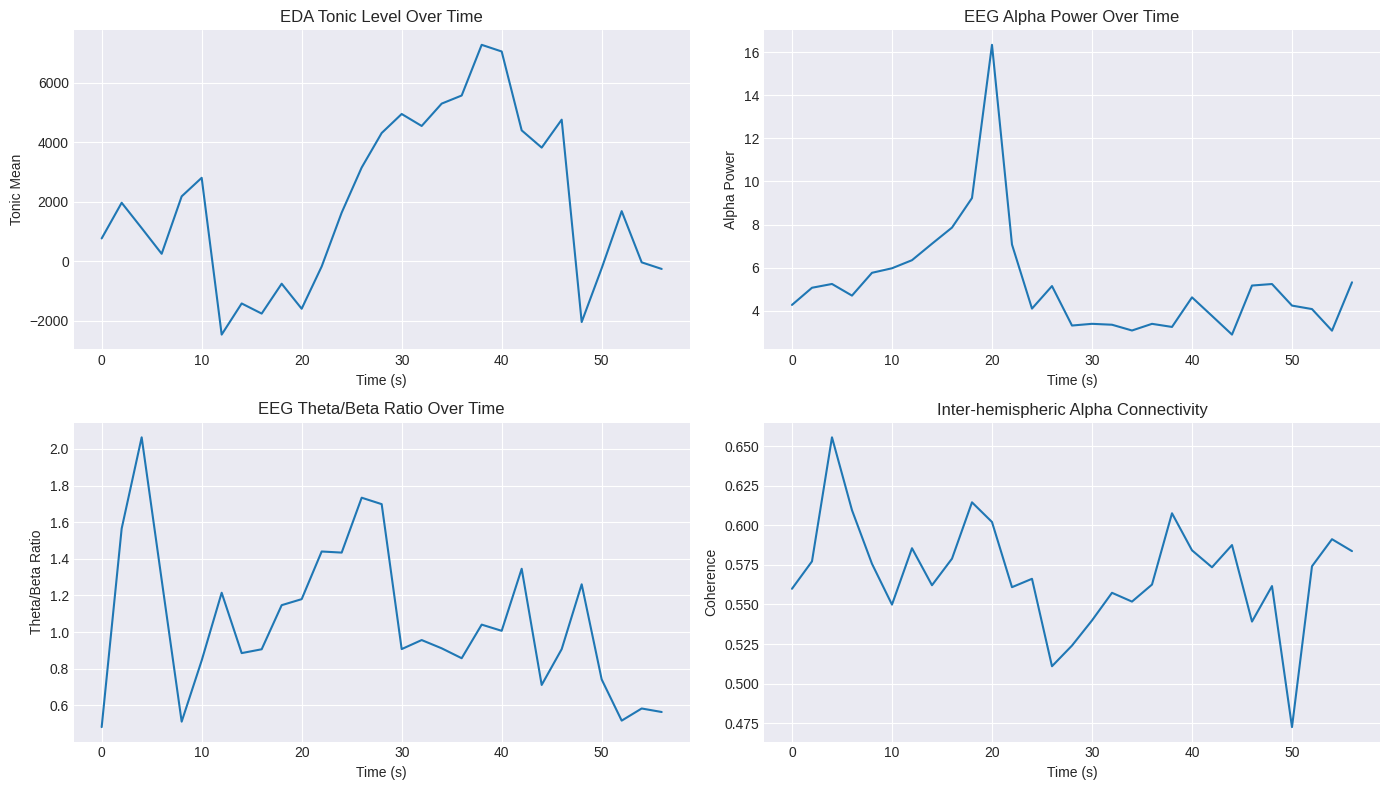

In [ ]:
# Visualize some key features over time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# EDA tonic mean over windows
axes[0, 0].plot(sample_features['window_start'], sample_features['eda_tonic_mean'])
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Tonic Mean')
axes[0, 0].set_title('EDA Tonic Level Over Time')

# EEG alpha power
axes[0, 1].plot(sample_features['window_start'], sample_features['eeg_alpha_mean'])
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Alpha Power')
axes[0, 1].set_title('EEG Alpha Power Over Time')

# Theta/Beta ratio
axes[1, 0].plot(sample_features['window_start'], sample_features['eeg_theta_beta_ratio'])
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Theta/Beta Ratio')
axes[1, 0].set_title('EEG Theta/Beta Ratio Over Time')

# Alpha connectivity
axes[1, 1].plot(sample_features['window_start'], sample_features['eeg_alpha_connectivity_mean'])
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Coherence')
axes[1, 1].set_title('Inter-hemispheric Alpha Connectivity')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_timeseries.png", dpi=150)
plt.show()

---
# 5. Emotion Recognition Model
---

Hierarchical CNN-LSTM-Transformer architecture for continuous valence/arousal prediction:
1. **CNN**: Local temporal patterns
2. **BiLSTM**: Sequential dynamics
3. **Transformer**: Global attention
4. **MC Dropout**: Uncertainty estimation

In [ ]:
# Configuration
@dataclass
class ModelConfig:
    input_dim: int = 50
    seq_len: int = 12

    # Multi-Scale CNN
    cnn_channels: List[int] = field(default_factory=lambda: [64, 128, 128])
    cnn_kernel_sizes: List[int] = field(default_factory=lambda: [3, 5, 7])
    cnn_dilations: List[int] = field(default_factory=lambda: [1, 2, 4])
    use_se_block: bool = True
    se_reduction: int = 16

    # LSTM
    lstm_hidden: int = 64
    lstm_layers: int = 2
    lstm_bidirectional: bool = True

    # Transformer
    transformer_dim: int = 256
    num_heads: int = 8
    n_transformer_blocks: int = 2
    ff_mult: int = 4

    # MoE
    use_moe: bool = False
    num_experts: int = 4
    top_k_experts: int = 2

    # Regularization
    dropout: float = 0.15
    attention_dropout: float = 0.1
    path_dropout: float = 0.1

    # Output
    output_dim: int = 2
    use_uncertainty: bool = True
    use_deep_supervision: bool = True

In [ ]:
# Building Blocks

class SqueezeExcitation(nn.Module):
    """Channel attention via squeeze-and-excitation."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excite = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        scale = self.squeeze(x).view(b, c)
        scale = self.excite(scale).view(b, c, 1)
        return x * scale


class GatedResidual(nn.Module):
    """Learnable gated residual connection."""
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x, residual):
        gate = self.gate(torch.cat([x, residual], dim=-1))
        return self.norm(gate * self.dropout(x) + (1 - gate) * residual)


class RelativePositionalEncoding(nn.Module):
    """Learnable relative positional encoding."""
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        self.rel_pos_embed = nn.Embedding(2 * max_len - 1, d_model)
        self.max_len = max_len

    def forward(self, seq_len: int):
        pos = torch.arange(seq_len, device=self.rel_pos_embed.weight.device)
        rel_pos = pos.unsqueeze(0) - pos.unsqueeze(1) + self.max_len - 1
        rel_pos = rel_pos.clamp(0, 2 * self.max_len - 2)
        return self.rel_pos_embed(rel_pos)

In [ ]:
class MultiScaleCNN(nn.Module):
    """Multi-scale CNN with dilated convolutions and SE blocks."""
    def __init__(self, input_dim, channels, kernel_sizes, dilations, use_se=True, se_reduction=16, dropout=0.1):
        super().__init__()
        self.branches = nn.ModuleList()
        for ks, dil in zip(kernel_sizes, dilations):
            padding = (ks - 1) * dil // 2
            self.branches.append(nn.Sequential(
                nn.Conv1d(input_dim, channels[0], kernel_size=ks, padding=padding, dilation=dil),
                nn.BatchNorm1d(channels[0]), nn.GELU(), nn.Dropout(dropout)
            ))

        fused = channels[0] * len(kernel_sizes)
        self.fusion = nn.Sequential(
            nn.Conv1d(fused, channels[1], kernel_size=1),
            nn.BatchNorm1d(channels[1]), nn.GELU(), nn.Dropout(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(channels[1], channels[2], kernel_size=3, padding=1),
            nn.BatchNorm1d(channels[2]), nn.GELU()
        )
        self.se = SqueezeExcitation(channels[2], se_reduction) if use_se else nn.Identity()
        self.residual = nn.Conv1d(input_dim, channels[2], 1) if input_dim != channels[2] else nn.Identity()
        self.output_dim = channels[2]

    def forward(self, x):
        x = x.transpose(1, 2)  # [B,T,F] -> [B,F,T]
        res = self.residual(x)
        x = torch.cat([b(x) for b in self.branches], dim=1)
        x = self.se(self.conv2(self.fusion(x)))
        return (x + res).transpose(1, 2)


class TemporalAttention(nn.Module):
    """Highlights important timesteps."""
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        w = F.softmax(self.attn(x).squeeze(-1), dim=-1)
        return x * self.dropout(w).unsqueeze(-1), w

In [ ]:
class EnhancedTransformerBlock(nn.Module):
    """Transformer with relative pos, gated residuals, stochastic depth."""
    def __init__(self, dim, num_heads=8, ff_mult=4, dropout=0.1, attn_dropout=0.1, path_dropout=0.1):
        super().__init__()
        self.num_heads, self.head_dim = num_heads, dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.rel_pos = RelativePositionalEncoding(self.head_dim)

        self.ff = nn.Sequential(
            nn.Linear(dim, ff_mult * dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(ff_mult * dim, dim)
        )
        self.gate1 = GatedResidual(dim, dropout)
        self.gate2 = GatedResidual(dim, dropout)
        self.path_drop = path_dropout

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        # rel_pos = self.rel_pos(T).permute(2, 0, 1)
        # attn = attn + (q @ rel_pos.unsqueeze(0)).mean(dim=-1, keepdim=True).squeeze(-1)
        attn = self.attn_drop(F.softmax(attn, dim=-1))

        out = self.proj((attn @ v).transpose(1, 2).reshape(B, T, D))

        if self.training and random.random() < self.path_drop:
            attn_out = x
        else:
            attn_out = self.gate1(out, x)

        if self.training and random.random() < self.path_drop:
            return attn_out
        return self.gate2(self.ff(attn_out), attn_out)

In [ ]:
class MixtureOfExperts(nn.Module):
    """MoE layer with load balancing."""
    def __init__(self, dim, num_experts=4, top_k=2, ff_mult=4, dropout=0.1):
        super().__init__()
        self.num_experts, self.top_k = num_experts, top_k
        self.router = nn.Linear(dim, num_experts, bias=False)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(dim, ff_mult*dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_mult*dim, dim))
            for _ in range(num_experts)
        ])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        logits = self.router(x)
        weights, indices = torch.topk(F.softmax(logits, dim=-1), self.top_k, dim=-1)
        weights = weights / weights.sum(dim=-1, keepdim=True)

        out = torch.zeros_like(x)
        for i, expert in enumerate(self.experts):
            w = (weights * (indices == i).float()).sum(dim=-1, keepdim=True)
            out = out + expert(x) * w

        # Load balance loss
        aux_loss = F.mse_loss(F.softmax(logits, -1).mean(dim=[0,1]), torch.ones(self.num_experts, device=x.device)/self.num_experts)
        return self.norm(out + x), aux_loss


class UncertaintyHead(nn.Module):
    """Predicts mean and log variance."""
    def __init__(self, input_dim, output_dim=1, dropout=0.1):
        super().__init__()
        self.mean = nn.Sequential(nn.LayerNorm(input_dim), nn.Linear(input_dim, input_dim//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(input_dim//2, output_dim))
        self.logvar = nn.Sequential(nn.LayerNorm(input_dim), nn.Linear(input_dim, input_dim//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(input_dim//2, output_dim))

    def forward(self, x):
        return self.mean(x), torch.clamp(self.logvar(x), -10, 10)

In [ ]:
class EnhancedHybridEmotionModel(nn.Module):
    """Complete Enhanced Hybrid Model."""

    def __init__(self, config=None):
        super().__init__()
        cfg = config or ModelConfig()
        self.config = cfg

        # CNN
        self.cnn = MultiScaleCNN(cfg.input_dim, cfg.cnn_channels, cfg.cnn_kernel_sizes, cfg.cnn_dilations, cfg.use_se_block, cfg.se_reduction, cfg.dropout)
        self.temporal_attn = TemporalAttention(self.cnn.output_dim, cfg.dropout)

        # LSTM
        self.lstm = nn.LSTM(self.cnn.output_dim, cfg.lstm_hidden, cfg.lstm_layers, batch_first=True, dropout=cfg.dropout if cfg.lstm_layers > 1 else 0, bidirectional=cfg.lstm_bidirectional)
        lstm_out = cfg.lstm_hidden * (2 if cfg.lstm_bidirectional else 1)

        # Transformer
        self.proj = nn.Linear(lstm_out, cfg.transformer_dim)
        self.transformers = nn.ModuleList([EnhancedTransformerBlock(cfg.transformer_dim, cfg.num_heads, cfg.ff_mult, cfg.dropout, cfg.attention_dropout, cfg.path_dropout) for _ in range(cfg.n_transformer_blocks)])

        # MoE
        self.use_moe = cfg.use_moe
        if cfg.use_moe:
            self.moe = MixtureOfExperts(cfg.transformer_dim, cfg.num_experts, cfg.top_k_experts, cfg.ff_mult, cfg.dropout)

        # Pooling
        self.pool = nn.Sequential(nn.Linear(cfg.transformer_dim, 1), nn.Softmax(dim=1))

        # Heads
        self.use_uncertainty = cfg.use_uncertainty
        if cfg.use_uncertainty:
            self.valence_head = UncertaintyHead(cfg.transformer_dim, 1, cfg.dropout)
            self.arousal_head = UncertaintyHead(cfg.transformer_dim, 1, cfg.dropout)
        else:
            self.head = nn.Sequential(nn.LayerNorm(cfg.transformer_dim), nn.Dropout(cfg.dropout), nn.Linear(cfg.transformer_dim, cfg.output_dim))

        # Deep supervision
        self.use_deep = cfg.use_deep_supervision
        if cfg.use_deep_supervision:
            self.deep_heads = nn.ModuleList([nn.Linear(cfg.transformer_dim, cfg.output_dim) for _ in range(cfg.n_transformer_blocks - 1)])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.LayerNorm, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, return_attention=False):
        out = {}

        # CNN + temporal attention
        x = self.cnn(x)
        x, temp_attn = self.temporal_attn(x)
        if return_attention: out['temporal_attention'] = temp_attn.detach()

        # LSTM
        x, _ = self.lstm(x)
        x = self.proj(x)

        # Transformer + deep supervision
        deep_preds = []
        for i, block in enumerate(self.transformers):
            x = block(x)
            if self.use_deep and i < len(self.transformers) - 1:
                deep_preds.append(self.deep_heads[i](x.mean(dim=1)))
        if self.use_deep and deep_preds:
            out['deep_preds'] = torch.stack(deep_preds, dim=0)

        # MoE
        if self.use_moe:
            x, aux = self.moe(x)
            out['moe_aux_loss'] = aux

        # Pooling
        attn = self.pool(x)
        if return_attention: out['pool_attention'] = attn.squeeze(-1).detach()
        x = (x * attn).sum(dim=1)

        # Prediction
        if self.use_uncertainty:
            out['valence'], out['valence_log_var'] = self.valence_head(x)
            out['arousal'], out['arousal_log_var'] = self.arousal_head(x)
        else:
            pred = self.head(x)
            out['valence'], out['arousal'] = pred[:, 0:1], pred[:, 1:2]

        return out

    def predict_with_uncertainty(self, x, n_samples=30):
        """MC Dropout for epistemic + aleatoric uncertainty."""
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

        v_preds, a_preds, v_vars, a_vars = [], [], [], []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                v_preds.append(out['valence'])
                a_preds.append(out['arousal'])
                if self.use_uncertainty:
                    v_vars.append(out['valence_log_var'].exp())
                    a_vars.append(out['arousal_log_var'].exp())

        v = torch.stack(v_preds)
        a = torch.stack(a_preds)

        result = {
            'valence_mean': v.mean(0), 'arousal_mean': a.mean(0),
            'valence_epistemic': v.std(0), 'arousal_epistemic': a.std(0)
        }
        if self.use_uncertainty:
            result['valence_aleatoric'] = torch.stack(v_vars).mean(0).sqrt()
            result['arousal_aleatoric'] = torch.stack(a_vars).mean(0).sqrt()
            result['valence_total'] = (result['valence_epistemic']**2 + result['valence_aleatoric']**2).sqrt()
            result['arousal_total'] = (result['arousal_epistemic']**2 + result['arousal_aleatoric']**2).sqrt()
        return result

In [ ]:
# Loss Functions

class GaussianNLLLoss(nn.Module):
    def forward(self, mean, log_var, target):
        return 0.5 * (log_var + (target - mean)**2 / log_var.exp()).mean()


class CombinedLoss(nn.Module):
    def __init__(self, use_uncertainty=True, deep_weight=0.3, moe_weight=0.01):
        super().__init__()
        self.use_unc = use_uncertainty
        self.deep_w, self.moe_w = deep_weight, moe_weight
        self.loss = GaussianNLLLoss() if use_uncertainty else nn.MSELoss()

    def forward(self, outputs, targets):
        v_t, a_t = targets[:, 0:1], targets[:, 1:2]

        if self.use_unc:
            v_loss = self.loss(outputs['valence'], outputs['valence_log_var'], v_t)
            a_loss = self.loss(outputs['arousal'], outputs['arousal_log_var'], a_t)
        else:
            v_loss = self.loss(outputs['valence'], v_t)
            a_loss = self.loss(outputs['arousal'], a_t)

        total = v_loss + a_loss
        losses = {'valence': v_loss, 'arousal': a_loss, 'main': total}

        if 'deep_preds' in outputs and outputs['deep_preds'] is not None:
            deep = sum(F.mse_loss(p, targets) for p in outputs['deep_preds']) / len(outputs['deep_preds'])
            losses['deep'] = deep
            total = total + self.deep_w * deep

        if 'moe_aux_loss' in outputs:
            losses['moe'] = outputs['moe_aux_loss']
            total = total + self.moe_w * outputs['moe_aux_loss']

        losses['total'] = total
        return losses

In [ ]:
## emotion dataset from the old code

class EmotionDataset(Dataset):
    """
    PyTorch Dataset for emotion recognition.
    """

    def __init__(self, features_list, labels, participant_ids=None):
        """
        Args:
#             features_list: List of DataFrames (windowed features per trial)
#             labels: Array of (valence, arousal) labels
#             participant_ids: Array of participant IDs for grouping
#         """
        self.features_list = features_list
        self.labels = labels
        self.participant_ids = participant_ids

        # Get feature columns (exclude window timing)
        sample_df = features_list[0]
        self.feature_cols = [c for c in sample_df.columns
                            if c not in ['window_start', 'window_end']]
        self.n_features = len(self.feature_cols)

    def __len__(self):
        return len(self.features_list)

    def __getitem__(self, idx):
        # Get features as numpy array
        features = self.features_list[idx][self.feature_cols].values.astype(np.float32)

        # Get labels (valence, arousal)
        label = self.labels[idx, :2].astype(np.float32)  # Only valence and arousal

        return torch.FloatTensor(features), torch.FloatTensor(label)


SEQ_LEN = 12

def collate_fn(batch):
    features, labels = zip(*batch)
    n_features = features[0].shape[1]
    x = torch.zeros(len(features), SEQ_LEN, n_features)

    for i, f in enumerate(features):
        L = f.shape[0]
        if L >= SEQ_LEN:
            start = np.random.randint(0, L - SEQ_LEN + 1)
            x[i] = f[start:start+SEQ_LEN]
        else:
            x[i, :L] = f

    y = torch.stack(labels)  # (B, 2)
    return x, y


print("Dataset class defined")

In [ ]:
# new Dataset from the hybrid notebook

class EmotionDatasetNew(Dataset): ### new one
    def __init__(self, features, targets, seq_len=12, stride=1):
        self.features = features.astype(np.float32)
        self.targets = targets.astype(np.float32)
        self.seq_len = seq_len
        self.idxs = list(range(0, len(features) - seq_len + 1, stride))

    def __len__(self): return len(self.idxs)

    def __getitem__(self, i):
        s = self.idxs[i]
        return torch.from_numpy(self.features[s:s+self.seq_len]), torch.from_numpy(self.targets[s+self.seq_len-1])


def make_synthetic_data(N=1200, F=50):
    X = np.random.randn(N, F).astype(np.float32)
    w1, w2 = np.random.randn(F), np.random.randn(F)
    v = np.tanh(X @ w1 / math.sqrt(F)) + 0.05 * np.random.randn(N)
    a = np.tanh(X @ w2 / math.sqrt(F) + 0.25 * np.sin(X[:, 0])) + 0.05 * np.random.randn(N)
    return X, np.stack([v, a], axis=1).astype(np.float32)

In [ ]:
# Training

def train_epoch(model, loader, optimizer, loss_fn, grad_clip=1.0):
    model.train()
    total, n = {}, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if x.dim() == 4:
            x = x.view(-1, x.size(-2), x.size(-1))  # (B*29, 12, 49)
            y = y.repeat_interleave(x.size(0) // y.size(0), dim=0)  # match labels
        optimizer.zero_grad(set_to_none=True)
        losses = loss_fn(model(x), y)
        losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        for k, v in losses.items():
            total[k] = total.get(k, 0) + v.item() * x.size(0)
        n += x.size(0)
    return {k: v/n for k, v in total.items()}


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total, n = {}, 0
    v_pred, a_pred, v_true, a_true = [], [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if x.dim() == 4:
            x = x.view(-1, x.size(-2), x.size(-1))
            y = y.repeat_interleave(x.size(0) // y.size(0), dim=0)
        out = model(x)
        losses = loss_fn(out, y)
        v_pred.append(out['valence'].cpu())
        a_pred.append(out['arousal'].cpu())
        v_true.append(y[:, 0:1].cpu())
        a_true.append(y[:, 1:2].cpu())
        for k, v in losses.items():
            total[k] = total.get(k, 0) + v.item() * x.size(0)
        n += x.size(0)

    metrics = {k: v/n for k, v in total.items()}
    metrics['valence_corr'] = float(np.corrcoef(torch.cat(v_pred).numpy().flatten(), torch.cat(v_true).numpy().flatten())[0,1])
    metrics['arousal_corr'] = float(np.corrcoef(torch.cat(a_pred).numpy().flatten(), torch.cat(a_true).numpy().flatten())[0,1])
    return metrics

In [ ]:
#### this cell comes from the new notebook

# Test the model

print('Creating model...')
config = ModelConfig()
model = EnhancedHybridEmotionModel(config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

# Forward test
x = torch.randn(8, 12, 50, device=device)
out = model(x, return_attention=True)
print('Outputs:')
for k, v in out.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k}: {tuple(v.shape)}')

# Uncertainty test
print('Uncertainty estimation:')
unc = model.predict_with_uncertainty(x[:4], n_samples=10)
for k, v in unc.items():
    print(f'  {k}: {tuple(v.shape)}')

print(' Model tests passed!')

Creating model...
Parameters: 2,675,336
Outputs:
  temporal_attention: (8, 12)
  deep_preds: (1, 8, 2)
  pool_attention: (8, 12)
  valence: (8, 1)
  valence_log_var: (8, 1)
  arousal: (8, 1)
  arousal_log_var: (8, 1)
Uncertainty estimation:
  valence_mean: (4, 1)
  arousal_mean: (4, 1)
  valence_epistemic: (4, 1)
  arousal_epistemic: (4, 1)
  valence_aleatoric: (4, 1)
  arousal_aleatoric: (4, 1)
  valence_total: (4, 1)
  arousal_total: (4, 1)
 Model tests passed!


---
# 6. ASD Physiological Simulation
---

Simulate ASD-associated physiological patterns based on literature:

**EEG Modifications:**
1. **Reduced alpha power** - Decreased mu suppression, reduced social processing
2. **Elevated theta** - Different from ADHD pattern, related to sensory processing
3. **Elevated gamma** - Sensory hypersensitivity, local over-connectivity
4. **Reduced long-range connectivity** - Impaired inter-hemispheric coherence

**EDA Modifications:**
5. **Elevated baseline (tonic)** - Hyperarousal at rest
6. **Atypical SCR responses** - Reduced amplitude, altered latency
7. **Slower habituation** - Prolonged responses to repeated stimuli

### References:
- Wang et al. (2013): EEG abnormalities in ASD
- Orekhova et al. (2007): High-frequency EEG in autism
- Neuhaus et al. (2016): EDA patterns in ASD

In [ ]:
class ASDSimulator:
    """
    Simulate ASD-associated physiological patterns.

    Based on literature findings:
    - EEG: Reduced alpha, elevated theta/gamma, reduced connectivity
    - EDA: Elevated tonic, atypical phasic, slower habituation

    Severity levels:
    - 'mild': Subtle modifications (Level 1 ASD)
    - 'moderate': Medium modifications (Level 2 ASD)
    - 'severe': Strong modifications (Level 3 ASD)
    """

    def __init__(self, severity='moderate', random_state=42):
        self.severity = severity
        self.rng = np.random.RandomState(random_state)

        # Define severity parameters
        self.severity_params = {
            'mild': {
                # EEG parameters
                'alpha_reduction': 0.15,      # 15% reduction in alpha
                'theta_elevation': 0.15,      # 15% increase in theta
                'gamma_elevation': 0.20,      # 20% increase in gamma
                'connectivity_reduction': 0.15,  # 15% reduction in coherence
                # EDA parameters
                'tonic_elevation': 0.15,      # 15% elevated baseline
                'scr_amplitude_reduction': 0.20,  # 20% reduced SCR amplitude
                'habituation_slowdown': 0.20,  # 20% slower habituation
                # Variability
                'variability_increase': 0.10   # 10% more variability
            },
            'moderate': {
                'alpha_reduction': 0.30,
                'theta_elevation': 0.25,
                'gamma_elevation': 0.35,
                'connectivity_reduction': 0.30,
                'tonic_elevation': 0.30,
                'scr_amplitude_reduction': 0.35,
                'habituation_slowdown': 0.35,
                'variability_increase': 0.20
            },
            'severe': {
                'alpha_reduction': 0.45,
                'theta_elevation': 0.40,
                'gamma_elevation': 0.50,
                'connectivity_reduction': 0.45,
                'tonic_elevation': 0.45,
                'scr_amplitude_reduction': 0.50,
                'habituation_slowdown': 0.50,
                'variability_increase': 0.30
            }
        }

        self.params = self.severity_params[severity]

        # Frequency bands
        self.freq_bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }

    # ==================== EEG Simulation ====================

    def _bandpass_filter(self, data, lowcut, highcut, fs, order=4):
        """Apply bandpass filter."""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = min(highcut / nyq, 0.99)
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def _extract_band(self, eeg, band, fs):
        """Extract frequency band from EEG."""
        low, high = self.freq_bands[band]
        return self._bandpass_filter(eeg, low, high, fs)

    def simulate_alpha_reduction(self, eeg, fs=128):
        """
        Reduce alpha power (8-13 Hz).

        ASD literature: Reduced mu suppression, reduced alpha during social tasks.
        """
        alpha_component = self._extract_band(eeg, 'alpha', fs)
        reduction = self.params['alpha_reduction']

        # Reduce alpha while preserving other frequencies
        eeg_modified = eeg - (reduction * alpha_component)

        return eeg_modified

    def simulate_theta_elevation(self, eeg, fs=128):
        """
        Elevate theta power (4-8 Hz).

        ASD literature: Elevated frontal theta during rest and tasks.
        """
        theta_component = self._extract_band(eeg, 'theta', fs)
        elevation = self.params['theta_elevation']

        # Add theta power
        eeg_modified = eeg + (elevation * theta_component)

        return eeg_modified

    def simulate_gamma_elevation(self, eeg, fs=128):
        """
        Elevate gamma power (30-45 Hz).

        ASD literature: Elevated high-frequency activity related to
        sensory hypersensitivity and local over-connectivity.
        """
        gamma_component = self._extract_band(eeg, 'gamma', fs)
        elevation = self.params['gamma_elevation']

        # Add gamma power
        eeg_modified = eeg + (elevation * gamma_component)

        return eeg_modified

    def simulate_connectivity_reduction(self, eeg, fs=128):
        """
        Reduce long-range connectivity by adding independent noise.

        ASD literature: Reduced inter-hemispheric coherence,
        impaired long-range functional connectivity.
        """
        reduction = self.params['connectivity_reduction']

        # Add independent noise to break coherence
        noise = self.rng.randn(*eeg.shape) * np.std(eeg, axis=-1, keepdims=True)

        eeg_modified = eeg + (reduction * noise)

        return eeg_modified

    def simulate_asd_eeg(self, eeg, fs=128):
        """
        Apply all ASD-related EEG modifications.

        Args:
            eeg: (channels, samples) or (trials, channels, samples)
            fs: Sampling frequency

        Returns:
            Modified EEG with ASD-like patterns
        """
        # Handle dimensionality
        single_trial = eeg.ndim == 2
        if single_trial:
            eeg = eeg[np.newaxis, :, :]

        eeg_asd = []
        for trial in eeg:
            # Apply modifications in sequence
            modified = trial.copy()
            modified = self.simulate_alpha_reduction(modified, fs)
            modified = self.simulate_theta_elevation(modified, fs)
            modified = self.simulate_gamma_elevation(modified, fs)
            modified = self.simulate_connectivity_reduction(modified, fs)
            eeg_asd.append(modified)

        eeg_asd = np.array(eeg_asd)
        return eeg_asd[0] if single_trial else eeg_asd

    # ==================== EDA Simulation ====================

    def simulate_tonic_elevation(self, eda, preprocessor):
        """
        Elevate tonic EDA level (baseline hyperarousal).

        ASD literature: Elevated skin conductance level at rest,
        reflecting chronic sympathetic activation.
        """
        decomposed = preprocessor.decompose_eda(eda)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']

        elevation = self.params['tonic_elevation']

        # Elevate tonic level
        tonic_elevated = tonic * (1 + elevation)

        # Reconstruct EDA
        eda_modified = tonic_elevated + phasic

        return eda_modified

    def simulate_scr_attenuation(self, eda, preprocessor):
        """
        Reduce SCR (phasic) amplitude.

        ASD literature: Reduced or atypical SCR responses,
        particularly to social stimuli.
        """
        decomposed = preprocessor.decompose_eda(eda)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']

        reduction = self.params['scr_amplitude_reduction']

        # Reduce phasic amplitude
        phasic_attenuated = phasic * (1 - reduction)

        # Reconstruct EDA
        eda_modified = tonic + phasic_attenuated

        return eda_modified

    def simulate_slower_habituation(self, eda, fs=128):
        """
        Simulate slower habituation by extending response decay.

        ASD literature: Prolonged physiological responses,
        slower return to baseline after stimulation.
        """
        slowdown = self.params['habituation_slowdown']

        # Apply temporal smoothing to simulate slower decay
        # Use larger kernel for more smoothing
        kernel_size = int(fs * (0.5 + slowdown))  # 0.5-1 second window
        if kernel_size % 2 == 0:
            kernel_size += 1

        eda_smoothed = median_filter(eda, size=kernel_size)

        # Blend original with smoothed (preserving some fast dynamics)
        eda_modified = (1 - slowdown) * eda + slowdown * eda_smoothed

        return eda_modified

    def simulate_asd_eda(self, eda, preprocessor, fs=128):
        """
        Apply all ASD-related EDA modifications.

        Args:
            eda: 1D array (samples,) or 2D (trials, samples)
            preprocessor: SignalPreprocessor instance
            fs: Sampling frequency

        Returns:
            Modified EDA with ASD-like patterns
        """
        single_trial = eda.ndim == 1
        if single_trial:
            eda = eda[np.newaxis, :]

        eda_asd = []
        for trial in eda:
            modified = trial.copy()
            modified = self.simulate_tonic_elevation(modified, preprocessor)
            modified = self.simulate_scr_attenuation(modified, preprocessor)
            modified = self.simulate_slower_habituation(modified, fs)
            eda_asd.append(modified)

        eda_asd = np.array(eda_asd)
        return eda_asd[0] if single_trial else eda_asd

    # ==================== Combined Simulation ====================

    def simulate_asd_physiology(self, eda, eeg, preprocessor, fs=128):
        """
        Apply all ASD modifications to both EDA and EEG.

        Args:
            eda: EDA signal
            eeg: EEG signal
            preprocessor: SignalPreprocessor instance
            fs: Sampling frequency

        Returns:
            dict with 'eda' and 'eeg' modified signals
        """
        return {
            'eda': self.simulate_asd_eda(eda, preprocessor, fs),
            'eeg': self.simulate_asd_eeg(eeg, fs)
        }

    def get_modification_summary(self):
        """Return summary of applied modifications."""
        return {
            'severity': self.severity,
            'parameters': self.params,
            'modifications': [
                f"Alpha power reduced by {self.params['alpha_reduction']*100:.0f}%",
                f"Theta power elevated by {self.params['theta_elevation']*100:.0f}%",
                f"Gamma power elevated by {self.params['gamma_elevation']*100:.0f}%",
                f"Connectivity reduced by {self.params['connectivity_reduction']*100:.0f}%",
                f"Tonic EDA elevated by {self.params['tonic_elevation']*100:.0f}%",
                f"SCR amplitude reduced by {self.params['scr_amplitude_reduction']*100:.0f}%",
                f"Habituation slowed by {self.params['habituation_slowdown']*100:.0f}%"
            ]
        }


# Initialize simulators for each severity level
asd_simulators = {
    'mild': ASDSimulator(severity='mild'),
    'moderate': ASDSimulator(severity='moderate'),
    'severe': ASDSimulator(severity='severe')
}

print("ASDSimulator initialized")
print("\nModerate severity modifications:")
for mod in asd_simulators['moderate'].get_modification_summary()['modifications']:
    print(f"  • {mod}")

ASDSimulator initialized

Moderate severity modifications:
  • Alpha power reduced by 30%
  • Theta power elevated by 25%
  • Gamma power elevated by 35%
  • Connectivity reduced by 30%
  • Tonic EDA elevated by 30%
  • SCR amplitude reduced by 35%
  • Habituation slowed by 35%


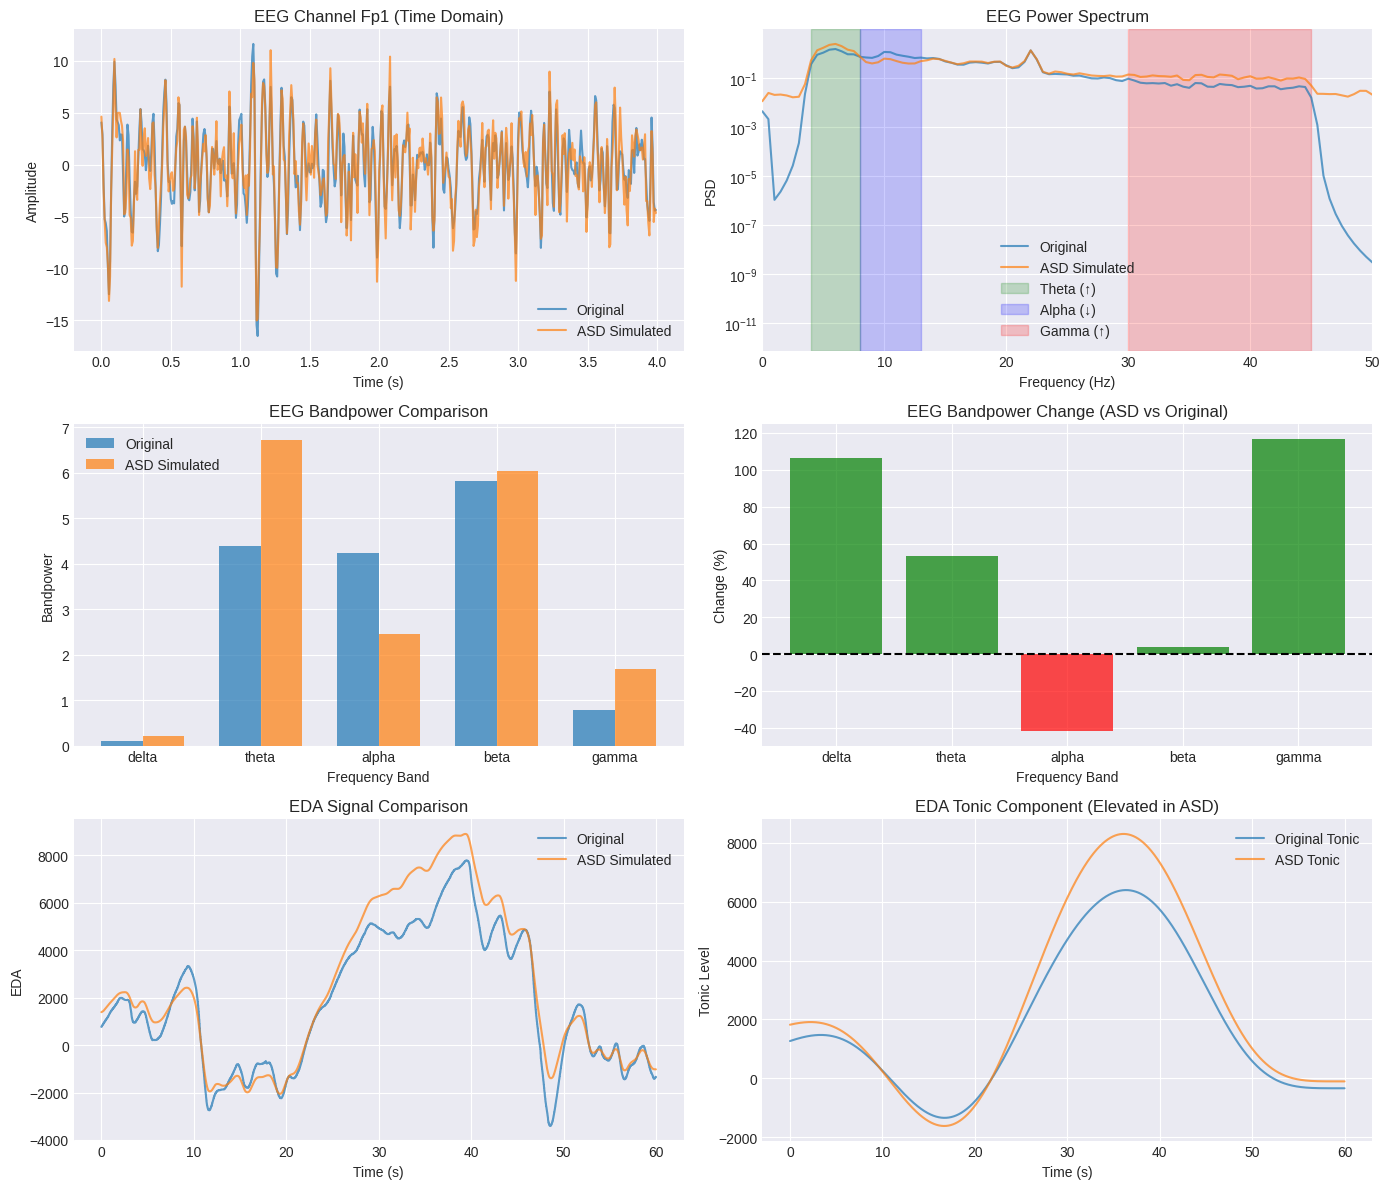


Bandpower changes:
  delta: +106.3%
  theta: +53.0%
  alpha: -41.7%
  beta: +3.9%
  gamma: +116.7%


In [ ]:
# Visualize ASD simulation effects
simulator = asd_simulators['moderate']

# Apply simulation
eeg_asd = simulator.simulate_asd_eeg(sample_eeg, fs=128)
eda_asd = simulator.simulate_asd_eda(sample_eda, preprocessor, fs=128)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Time axis
t = np.arange(len(sample_eda)) / 128

# EEG comparison (first 4 seconds)
t_short = t[:512]
axes[0, 0].plot(t_short, sample_eeg[0, :512], alpha=0.7, label='Original')
axes[0, 0].plot(t_short, eeg_asd[0, :512], alpha=0.7, label='ASD Simulated')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('EEG Channel Fp1 (Time Domain)')
axes[0, 0].legend()

# EEG Power Spectrum comparison
freqs_orig, psd_orig = welch(sample_eeg[0], fs=128, nperseg=256)
freqs_asd, psd_asd = welch(eeg_asd[0], fs=128, nperseg=256)

axes[0, 1].semilogy(freqs_orig, psd_orig, alpha=0.7, label='Original')
axes[0, 1].semilogy(freqs_asd, psd_asd, alpha=0.7, label='ASD Simulated')
axes[0, 1].set_xlabel('Frequency (Hz)')
axes[0, 1].set_ylabel('PSD')
axes[0, 1].set_title('EEG Power Spectrum')
axes[0, 1].set_xlim([0, 50])
axes[0, 1].axvspan(4, 8, alpha=0.2, color='green', label='Theta (↑)')
axes[0, 1].axvspan(8, 13, alpha=0.2, color='blue', label='Alpha (↓)')
axes[0, 1].axvspan(30, 45, alpha=0.2, color='red', label='Gamma (↑)')
axes[0, 1].legend()

# Bandpower comparison
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
bp_orig = []
bp_asd = []

for band in bands:
    low, high = extractor.freq_bands[band]
    idx = np.logical_and(freqs_orig >= low, freqs_orig <= high)
    bp_orig.append(np.trapz(psd_orig[idx], freqs_orig[idx]))
    bp_asd.append(np.trapz(psd_asd[idx], freqs_asd[idx]))

x = np.arange(len(bands))
width = 0.35
axes[1, 0].bar(x - width/2, bp_orig, width, label='Original', alpha=0.7)
axes[1, 0].bar(x + width/2, bp_asd, width, label='ASD Simulated', alpha=0.7)
axes[1, 0].set_xlabel('Frequency Band')
axes[1, 0].set_ylabel('Bandpower')
axes[1, 0].set_title('EEG Bandpower Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(bands)
axes[1, 0].legend()

# Percent change in bandpower
pct_change = [(a - o) / o * 100 for o, a in zip(bp_orig, bp_asd)]
colors = ['green' if p > 0 else 'red' for p in pct_change]
axes[1, 1].bar(bands, pct_change, color=colors, alpha=0.7)
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_xlabel('Frequency Band')
axes[1, 1].set_ylabel('Change (%)')
axes[1, 1].set_title('EEG Bandpower Change (ASD vs Original)')

# EDA comparison
axes[2, 0].plot(t, sample_eda, alpha=0.7, label='Original')
axes[2, 0].plot(t, eda_asd, alpha=0.7, label='ASD Simulated')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('EDA')
axes[2, 0].set_title('EDA Signal Comparison')
axes[2, 0].legend()

# EDA decomposition comparison
eda_decomp_orig = preprocessor.decompose_eda(sample_eda)
eda_decomp_asd = preprocessor.decompose_eda(eda_asd)

axes[2, 1].plot(t, eda_decomp_orig['tonic'], alpha=0.7, label='Original Tonic')
axes[2, 1].plot(t, eda_decomp_asd['tonic'], alpha=0.7, label='ASD Tonic')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Tonic Level')
axes[2, 1].set_title('EDA Tonic Component (Elevated in ASD)')
axes[2, 1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/asd_simulation_comparison.png", dpi=150)
plt.show()

print("\nBandpower changes:")
for band, change in zip(bands, pct_change):
    print(f"  {band}: {change:+.1f}%")

---
# 7. Therapeutic Music Generation
---

Map predicted valence/arousal to musical parameters:
- **Arousal** → Tempo, note density, rhythmic complexity
- **Valence** → Mode (major/minor), harmonic complexity

In [ ]:
class TherapeuticMusicGenerator:
    """
    Generate therapeutic music based on predicted emotional state.

    Emotion-to-music mapping:
    - High valence + High arousal → Fast, major, complex (Happy)
    - High valence + Low arousal → Slow, major, simple (Peaceful)
    - Low valence + High arousal → Fast, minor, complex (Anxious/Tense)
    - Low valence + Low arousal → Slow, minor, simple (Sad)
    """

    def __init__(self):
        # Musical scales
        self.scales = {
            'major': [0, 2, 4, 5, 7, 9, 11],
            'minor': [0, 2, 3, 5, 7, 8, 10],
            'dorian': [0, 2, 3, 5, 7, 9, 10],
            'mixolydian': [0, 2, 4, 5, 7, 9, 10],
            'pentatonic_major': [0, 2, 4, 7, 9],
            'pentatonic_minor': [0, 3, 5, 7, 10]
        }

        # Chord progressions by mood
        self.chord_progressions = {
            'happy': [[0, 4, 7], [5, 9, 12], [7, 11, 14], [0, 4, 7]],  # I-IV-V-I
            'peaceful': [[0, 4, 7], [5, 9, 12], [2, 5, 9], [0, 4, 7]],  # I-IV-ii-I
            'sad': [[0, 3, 7], [5, 8, 12], [7, 10, 14], [0, 3, 7]],  # i-iv-v-i
            'tense': [[0, 3, 7], [1, 4, 8], [7, 10, 14], [0, 3, 7]]  # i-bII-v-i
        }

        # Note durations (in beats)
        self.durations = {
            'whole': 4.0,
            'half': 2.0,
            'quarter': 1.0,
            'eighth': 0.5,
            'sixteenth': 0.25
        }

    def emotion_to_music_params(self, valence, arousal):
        """
        Map valence/arousal to musical parameters.

        Args:
            valence: 0-1 (negative to positive)
            arousal: 0-1 (calm to excited)

        Returns:
            dict of musical parameters
        """
        params = {}

        # Tempo: 60-140 BPM based on arousal
        params['tempo'] = int(60 + arousal * 80)

        # Note density: notes per beat
        params['note_density'] = 0.5 + arousal * 1.5  # 0.5 to 2.0

        # Scale/Mode selection
        if valence > 0.6:
            params['scale'] = 'major' if arousal > 0.5 else 'pentatonic_major'
        elif valence < 0.4:
            params['scale'] = 'minor' if arousal > 0.5 else 'pentatonic_minor'
        else:
            params['scale'] = 'dorian' if arousal > 0.5 else 'mixolydian'

        # Mood category
        if valence > 0.5 and arousal > 0.5:
            params['mood'] = 'happy'
        elif valence > 0.5 and arousal <= 0.5:
            params['mood'] = 'peaceful'
        elif valence <= 0.5 and arousal > 0.5:
            params['mood'] = 'tense'
        else:
            params['mood'] = 'sad'

        # Base pitch (MIDI note number)
        params['base_pitch'] = 60  # Middle C

        # Rhythmic complexity
        params['rhythmic_complexity'] = arousal  # 0-1

        # Harmonic complexity
        params['harmonic_complexity'] = 0.3 + valence * 0.4  # 0.3-0.7

        # Dynamics
        params['velocity_base'] = int(60 + arousal * 40)  # 60-100
        params['velocity_variation'] = int(arousal * 20)  # 0-20

        return params

    def generate_melody(self, params, duration=16, seed=42):
        """
        Generate a melody based on musical parameters.

        Args:
            params: Musical parameters from emotion_to_music_params
            duration: Duration in beats
            seed: Random seed

        Returns:
            List of (pitch, start_time, duration, velocity) tuples
        """
        rng = np.random.RandomState(seed)

        scale = self.scales[params['scale']]
        base_pitch = params['base_pitch']

        melody = []
        current_time = 0

        while current_time < duration:
            # Choose note duration based on complexity
            if params['rhythmic_complexity'] > 0.7:
                dur_choices = [0.25, 0.5, 0.5, 1.0]
            elif params['rhythmic_complexity'] > 0.4:
                dur_choices = [0.5, 0.5, 1.0, 1.0]
            else:
                dur_choices = [1.0, 1.0, 2.0, 2.0]

            note_dur = rng.choice(dur_choices)

            # Choose pitch from scale
            octave = rng.choice([0, 0, 12, 12, -12])  # Mostly in base octave
            scale_degree = rng.choice(len(scale))
            pitch = base_pitch + scale[scale_degree] + octave

            # Velocity with variation
            velocity = params['velocity_base'] + rng.randint(
                -params['velocity_variation'],
                params['velocity_variation'] + 1
            )
            velocity = np.clip(velocity, 40, 127)

            melody.append((pitch, current_time, note_dur, velocity))
            current_time += note_dur

        return melody

    def generate_harmony(self, params, melody):
        """
        Generate chord accompaniment.

        Args:
            params: Musical parameters
            melody: Generated melody

        Returns:
            List of chord events
        """
        progression = self.chord_progressions[params['mood']]
        base_pitch = params['base_pitch'] - 12  # One octave lower

        harmony = []
        chord_duration = 4.0  # One chord per bar

        total_duration = max(note[1] + note[2] for note in melody)
        current_time = 0
        chord_idx = 0

        while current_time < total_duration:
            chord = progression[chord_idx % len(progression)]
            velocity = int(params['velocity_base'] * 0.7)  # Softer than melody

            for interval in chord:
                pitch = base_pitch + interval
                harmony.append((pitch, current_time, chord_duration, velocity))

            current_time += chord_duration
            chord_idx += 1

        return harmony

    def create_midi(self, melody, harmony, params, filename):
        """
        Create MIDI file from melody and harmony.

        Args:
            melody: List of melody notes
            harmony: List of harmony chords
            params: Musical parameters (for tempo)
            filename: Output filename
        """
        midi = MIDIFile(2)  # Two tracks: melody and harmony

        # Track 0: Melody
        track_melody = 0
        midi.addTrackName(track_melody, 0, "Melody")
        midi.addTempo(track_melody, 0, params['tempo'])
        midi.addProgramChange(track_melody, 0, 0, 0)  # Piano

        for pitch, start, dur, vel in melody:
            midi.addNote(track_melody, 0, int(pitch), start, dur, int(vel))

        # Track 1: Harmony
        track_harmony = 1
        midi.addTrackName(track_harmony, 0, "Harmony")
        midi.addProgramChange(track_harmony, 1, 0, 0)  # Piano

        for pitch, start, dur, vel in harmony:
            midi.addNote(track_harmony, 1, int(pitch), start, dur, int(vel))

        # Write to file
        with open(filename, 'wb') as f:
            midi.writeFile(f)

        return filename

    def generate_therapeutic_music(self, valence, arousal, filename, duration=16):
        """
        Full pipeline: emotion → parameters → melody → harmony → MIDI.

        Args:
            valence: Predicted valence (0-1)
            arousal: Predicted arousal (0-1)
            filename: Output MIDI filename
            duration: Music duration in beats

        Returns:
            dict with parameters and filename
        """
        # Map emotion to music parameters
        params = self.emotion_to_music_params(valence, arousal)

        # Generate music
        melody = self.generate_melody(params, duration)
        harmony = self.generate_harmony(params, melody)

        # Create MIDI
        self.create_midi(melody, harmony, params, filename)

        return {
            'valence': valence,
            'arousal': arousal,
            'parameters': params,
            'filename': filename
        }


# Initialize music generator
music_gen = TherapeuticMusicGenerator()
print("TherapeuticMusicGenerator initialized")

TherapeuticMusicGenerator initialized


In [ ]:
# Test music generation for different emotional states
test_emotions = [
    (0.8, 0.8, 'happy'),
    (0.8, 0.2, 'peaceful'),
    (0.2, 0.8, 'tense'),
    (0.2, 0.2, 'sad')
]

print("Music parameters for different emotional states:\n")
for valence, arousal, label in test_emotions:
    params = music_gen.emotion_to_music_params(valence, arousal)
    print(f"{label.upper()} (V={valence}, A={arousal}):")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Note density: {params['note_density']:.2f}")
    print(f"  Velocity: {params['velocity_base']}±{params['velocity_variation']}")
    print()

Music parameters for different emotional states:

HAPPY (V=0.8, A=0.8):
  Tempo: 124 BPM
  Scale: major
  Note density: 1.70
  Velocity: 92±16

PEACEFUL (V=0.8, A=0.2):
  Tempo: 76 BPM
  Scale: pentatonic_major
  Note density: 0.80
  Velocity: 68±4

TENSE (V=0.2, A=0.8):
  Tempo: 124 BPM
  Scale: minor
  Note density: 1.70
  Velocity: 92±16

SAD (V=0.2, A=0.2):
  Tempo: 76 BPM
  Scale: pentatonic_minor
  Note density: 0.80
  Velocity: 68±4



---
# 8. Data Loading, Experiments and Results
---

Run the complete pipeline:
1. Load and preprocess data
2. Extract features
3. Train emotion recognition model
4. Compare NT vs ASD-simulated predictions
5. Analyze music parameter differences

In [ ]:
import os

FEATURES_DIR = '/content/drive/MyDrive/2025/ASD_features'
os.makedirs(FEATURES_DIR, exist_ok=True)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

EXPECTED_DIM = 49  # e.g., 49

all_features = []
all_labels = []
all_pids = []

for pid in range(1, 33):
    file_path = os.path.join(FEATURES_DIR, f'pid{pid}_features.npz')

    if not os.path.exists(file_path):
        continue

    data = np.load(file_path, allow_pickle=True)
    features = data['features']   # (n_trials, n_windows, n_features)
    labels = data['labels']

    # After loading features from .npz
    trial_features = features[0][:, :EXPECTED_DIM]  # first trial
    feature_cols = [f'feat_{i}' for i in range(trial_features.shape[1])]  # simple generic column names

    # ====== per-participant z-score normalization ======
    # Concatenate all windows from all trials to fit scaler
    concat_features = np.concatenate(features, axis=0)[:, :EXPECTED_DIM]  # (n_trials * n_windows, n_features)
    scaler = StandardScaler()
    scaler.fit(concat_features)

    # Transform each trial
    for trial_idx in range(features.shape[0]):
        trial_features = features[trial_idx][:, :EXPECTED_DIM]
        trial_features_scaled = scaler.transform(trial_features)

        df = pd.DataFrame(trial_features_scaled, columns=feature_cols)
        all_features.append(df)
        all_labels.append(labels[trial_idx])
        all_pids.append(pid)

all_labels = np.array(all_labels)
all_pids = np.array(all_pids)

print(len(all_features), all_labels.shape, all_pids.shape)


1280 (1280, 4) (1280,)


In [ ]:
# --- pick only valence/arousal ---
all_labels_va = all_labels[:, :2].astype(np.float32)   # (1280, 2)

# --- convert list[DataFrame] -> list[np.ndarray] ---
feature_cols = [c for c in all_features[0].columns if c not in ['window_start', 'window_end']]
all_features_np = [df[feature_cols].values.astype(np.float32) for df in all_features]

all_features_np = np.asarray(all_features_np)


In [ ]:
len(all_pids)

1280

In [ ]:
dataset = EmotionDataset(all_features, all_labels_va, all_pids)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

config = ModelConfig(input_dim=49, seq_len=12)
model = EnhancedHybridEmotionModel(config).to(device)

In [ ]:
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Subset
import numpy as np

np.random.seed(SEED)

# ---- participant split ----
unique_pids = np.unique(all_pids)
np.random.shuffle(unique_pids)

n_train_pids = int(0.8 * len(unique_pids))
train_pids = set(unique_pids[:n_train_pids])
test_pids  = set(unique_pids[n_train_pids:])

train_idx = [i for i, pid in enumerate(all_pids) if pid in train_pids]
test_idx  = [i for i, pid in enumerate(all_pids) if pid in test_pids]

print(f"Train trials: {len(train_idx)}, Test trials: {len(test_idx)}")

# ---- fit scaler on training windows only ----
feature_cols = [c for c in all_features[0].columns if c not in ['window_start','window_end']]
train_feature_values = np.concatenate([all_features[i][feature_cols].values for i in train_idx], axis=0)

scaler = RobustScaler()
scaler.fit(train_feature_values)

# ---- apply scaler to TRAIN ONLY (minimal but real) ----
all_features_scaled = list(all_features)  # shallow copy
for i in train_idx:
    df = all_features_scaled[i].copy()
    df[feature_cols] = scaler.transform(df[feature_cols].values)
    all_features_scaled[i] = df

# ---- dataset + subset loaders ----
dataset = EmotionDataset(all_features_scaled, all_labels_va, all_pids)  # use your trial-based class name

train_ds = Subset(dataset, train_idx)
# test_ds  = Subset(dataset, test_idx)
val_ds   = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_fn)
# test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, collate_fn=collate_fn)

# ---- model ----
# config = ModelConfig(input_dim=49, seq_len=12)
# model = EnhancedHybridEmotionModel(config).to(device)


Train trials: 1000, Test trials: 280


In [ ]:
print("Creating model...")
config = ModelConfig(input_dim=EXPECTED_DIM, seq_len=12)  # EXPECTED_DIM is 49
model = EnhancedHybridEmotionModel(config).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=5e-4)

# ===== Warmup configuration =====
warmup_epochs = 10  # train first 10 epochs with MSE
loss_fn_mse = CombinedLoss(use_uncertainty=False)  # effectively MSELoss
loss_fn_nll = CombinedLoss(use_uncertainty=True)   # main loss

n_epochs = 50
best_val = float("inf")
best_corr_score = -float("inf")
train_losses = []
val_losses = []
v_corrs = []
a_corrs = []

CKPT_PATH = f"{MODEL_DIR}/best_enhanced_hybrid_2.pt"
CORR_MODEL_PATH = f"{MODEL_DIR}/best_corr_model.pt"

print("\nStarting training...")
for epoch in range(1, n_epochs + 1):
    # Select loss function
    if epoch <= warmup_epochs:
        loss_fn = loss_fn_mse
    else:
        loss_fn = loss_fn_nll

    # Train and evaluate
    tr = train_epoch(model, train_loader, optimizer, loss_fn, grad_clip=1.0)
    va = evaluate(model, val_loader, loss_fn)

    # Record metrics
    train_losses.append(tr["total"])
    val_losses.append(va["total"])
    v_corrs.append(va["valence_corr"])
    a_corrs.append(va["arousal_corr"])

    # Save best model
    if va["total"] < best_val:
        best_val = va["total"]
        torch.save(model.state_dict(), CKPT_PATH)

    score = va["arousal_corr"]

    if score > best_corr_score and epoch > 10:
        best_corr_score = score
        torch.save(model.state_dict(), CORR_MODEL_PATH)

    if epoch % 2 == 0 or epoch == 1:
        phase = "MSE warmup" if epoch <= warmup_epochs else "NLL"
        print(f"Epoch {epoch:02d} [{phase}] | train={tr['total']:.4f} | val={va['total']:.4f} | "
              f"v_corr={va['valence_corr']:.3f} | a_corr={va['arousal_corr']:.3f}")

print(f"\nTraining complete. Best val loss: {best_val:.4f}")

Creating model...

Starting training...
Epoch 01 [MSE warmup] | train=0.1946 | val=0.1412 | v_corr=0.153 | a_corr=0.037
Epoch 02 [MSE warmup] | train=0.1483 | val=0.1383 | v_corr=0.169 | a_corr=0.003
Epoch 04 [MSE warmup] | train=0.1454 | val=0.1370 | v_corr=0.166 | a_corr=0.008
Epoch 06 [MSE warmup] | train=0.1448 | val=0.1363 | v_corr=0.200 | a_corr=-0.011
Epoch 08 [MSE warmup] | train=0.1444 | val=0.1365 | v_corr=0.156 | a_corr=0.010
Epoch 10 [MSE warmup] | train=0.1442 | val=0.1361 | v_corr=0.170 | a_corr=0.028
Epoch 12 [NLL] | train=-0.5480 | val=-0.7348 | v_corr=0.192 | a_corr=-0.013
Epoch 14 [NLL] | train=-1.1552 | val=-1.3396 | v_corr=0.167 | a_corr=0.003
Epoch 16 [NLL] | train=-1.6489 | val=-1.7503 | v_corr=0.174 | a_corr=0.031
Epoch 18 [NLL] | train=-1.7260 | val=-1.7974 | v_corr=0.142 | a_corr=-0.011
Epoch 20 [NLL] | train=-1.7158 | val=-1.7971 | v_corr=0.156 | a_corr=0.051
Epoch 22 [NLL] | train=-1.7454 | val=-1.8182 | v_corr=0.180 | a_corr=0.062
Epoch 24 [NLL] | train=-1.7

In [ ]:
best_corr_score

0.3164954107130989

In [ ]:
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 12, 49]) torch.Size([64, 2])


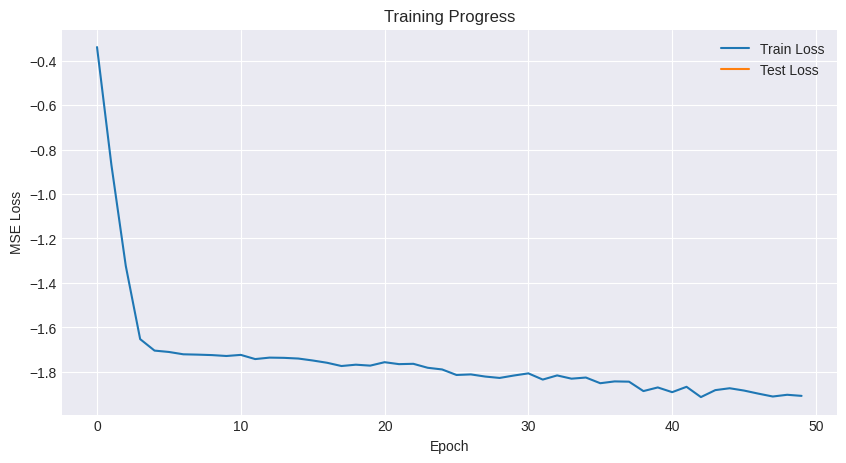

In [ ]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss')
ax.plot(test_losses, label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Progress')
ax.legend()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()

In [ ]:
def predict_with_uncertainty_new(model, x, scaler=None, n_samples=20, device='cpu', seq_len=12):
    model.train()  # enable dropout

    # x: (n_windows, n_features)
    if scaler is not None:
        x = scaler.transform(x)

    # crop/pad to seq_len
    T, F = x.shape
    if T >= seq_len:
        x_seq = x[-seq_len:, :]  # or random crop
    else:
        pad = np.zeros((seq_len - T, F), dtype=np.float32)
        x_seq = np.concatenate([x, pad], axis=0)

    x_tensor = torch.from_numpy(x_seq).float().unsqueeze(0).to(device)  # (1, 12, F)

    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            out = model(x_tensor)
            v = out['valence'].item()
            a = out['arousal'].item()
            preds.append([v, a])

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred  = preds.std(axis=0)

    model.eval()
    return mean_pred, std_pred


In [ ]:
def check_prediction_variance(model, sample_trials, scaler=None, device="cpu"):
    conds = ["neurotypical", "mild", "moderate", "severe"]

    for c in conds:
        preds_v, preds_a = [], []

        for trial_idx in sample_trials:
            eda = loader.load_participant(all_pids[trial_idx])['eda'][trial_idx % 40]
            eeg = loader.load_participant(all_pids[trial_idx])['eeg'][trial_idx % 40]

            if c != "neurotypical":
                sim = asd_simulators[c]
                eda = sim.simulate_asd_eda(eda, preprocessor)
                eeg = sim.simulate_asd_eeg(eeg)

            df = extractor.extract_windowed_features(eda, eeg)
            cols = [k for k in df.columns if k not in ["window_start", "window_end"]]
            x = df[cols].values.astype(np.float32)

            mean_pred, _ = predict_with_uncertainty_new(model, x, scaler=scaler, n_samples=5, device=device)
            preds_v.append(mean_pred[0])
            preds_a.append(mean_pred[1])

        print(f"\n{c.upper()}")
        print(f"Valence mean/std: {np.mean(preds_v):.4f} / {np.std(preds_v):.6f}")
        print(f"Arousal mean/std: {np.mean(preds_a):.4f} / {np.std(preds_a):.6f}")


In [ ]:
# Load best model
model.load_state_dict(torch.load(f"{MODEL_DIR}/best_enhanced_hybrid_2.pt"))

# model.load_state_dict(torch.load(f"{MODEL_DIR}/best_corr_model.pt"))

model.eval()

# Compare NT vs ASD predictions across severity levels
print("Comparing Neurotypical vs ASD-simulated predictions...\n")

results = {
    'condition': [],
    'valence_mean': [],
    'valence_std': [],
    'arousal_mean': [],
    'arousal_std': [],
    'uncertainty_valence': [],
    'uncertainty_arousal': []
}

# Sample trials for analysis
# sample_trials = test_idx[:100]  # Use 20 test trials
np.random.seed(42)  # for reproducibility
sample_trials = np.random.choice(test_idx, size=100, replace=False)

# pick one NT trial to define extractor schema
trial_idx = sample_trials[0]
eda = loader.load_participant(all_pids[trial_idx])['eda'][trial_idx % 40]
eeg = loader.load_participant(all_pids[trial_idx])['eeg'][trial_idx % 40]

tmp = extractor.extract_windowed_features(eda, eeg).drop(columns=["window_start","window_end"], errors="ignore")
TRAIN_COLS = list(tmp.columns)
EXPECTED_DIM = len(TRAIN_COLS)
print("Using extractor schema. EXPECTED_DIM =", EXPECTED_DIM)


print('fitting extractor robust scaler:')
def fit_extractor_robust_scaler(train_trials, max_trials=200):
    Xs = []
    for trial_idx in train_trials[:max_trials]:
        eda = loader.load_participant(all_pids[trial_idx])['eda'][trial_idx % 40]
        eeg = loader.load_participant(all_pids[trial_idx])['eeg'][trial_idx % 40]
        df = extractor.extract_windowed_features(eda, eeg).drop(columns=["window_start","window_end"], errors="ignore")
        df = df.reindex(columns=TRAIN_COLS, fill_value=0.0)
        Xs.append(df.to_numpy(dtype=np.float32))
    X = np.concatenate(Xs, axis=0)
    sc = RobustScaler()
    sc.fit(X)
    return sc

extractor_scaler = fit_extractor_robust_scaler(train_idx, max_trials=50)
print("extractor_scaler fitted")

for condition in ['neurotypical', 'mild', 'moderate', 'severe']:
    valences = []
    arousals = []
    uncertainties_v = []
    uncertainties_a = []

    for trial_idx in sample_trials:
        # Get original data
        eda = loader.load_participant(all_pids[trial_idx])['eda'][trial_idx % 40]
        eeg = loader.load_participant(all_pids[trial_idx])['eeg'][trial_idx % 40]

        # Apply ASD simulation if needed
        if condition != 'neurotypical':
            simulator = asd_simulators[condition]
            eda = simulator.simulate_asd_eda(eda, preprocessor)
            eeg = simulator.simulate_asd_eeg(eeg)

        # Extract features
        features_df = extractor.extract_windowed_features(eda, eeg)
        # feature_cols = [c for c in features_df.columns if c not in ['window_start', 'window_end']]
        # features = features_df[feature_cols].values.astype(np.float32)
        ## edits, 20260220:
        # 1) drop timing cols if present
        features_df = features_df.drop(columns=["window_start", "window_end"], errors="ignore")

        # 2) ALIGN to training schema + order (missing cols filled with 0)
        features_df = features_df.reindex(columns=TRAIN_COLS, fill_value=0.0)

        # 3) numpy array with guaranteed shape (n_windows, 49)
        features = features_df.to_numpy(dtype=np.float32)

        # optional sanity check (keep while debugging)
        assert features.shape[1] == EXPECTED_DIM, features.shape

        # print(features.shape, features.mean(), features.std())

        # Predict with uncertainty
        mean_pred, std_pred = predict_with_uncertainty_new(model, features, scaler=extractor_scaler, n_samples=20, device=device)

        valences.append(mean_pred[0])
        arousals.append(mean_pred[1])
        uncertainties_v.append(std_pred[0])
        uncertainties_a.append(std_pred[1])

    results['condition'].append(condition)
    results['valence_mean'].append(np.mean(valences))
    results['valence_std'].append(np.std(valences))
    results['arousal_mean'].append(np.mean(arousals))
    results['arousal_std'].append(np.std(arousals))
    results['uncertainty_valence'].append(np.mean(uncertainties_v))
    results['uncertainty_arousal'].append(np.mean(uncertainties_a))

    print(f"{condition.upper()}:")
    print(f"  Valence: {np.mean(valences):.3f} ± {np.std(valences):.3f}")
    print(f"  Arousal: {np.mean(arousals):.3f} ± {np.std(arousals):.3f}")
    print(f"  Uncertainty (V/A): {np.mean(uncertainties_v):.3f} / {np.mean(uncertainties_a):.3f}")
    print()

results_df = pd.DataFrame(results)
results_df.to_csv(f"{RESULTS_DIR}/nt_vs_asd_comparison.csv", index=False)

Comparing Neurotypical vs ASD-simulated predictions...

Using extractor schema. EXPECTED_DIM = 49
fitting extractor robust scaler:
extractor_scaler fitted
NEUROTYPICAL:
  Valence: 0.195 ± 0.153
  Arousal: 0.236 ± 0.101
  Uncertainty (V/A): 0.031 / 0.029

MILD:
  Valence: 0.184 ± 0.159
  Arousal: 0.227 ± 0.104
  Uncertainty (V/A): 0.031 / 0.029

MODERATE:
  Valence: 0.167 ± 0.157
  Arousal: 0.211 ± 0.106
  Uncertainty (V/A): 0.030 / 0.029

SEVERE:
  Valence: 0.152 ± 0.144
  Arousal: 0.196 ± 0.099
  Uncertainty (V/A): 0.029 / 0.031



In [ ]:
# Visualize NT vs ASD comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

conditions = results_df['condition']
x = np.arange(len(conditions))

# Valence comparison
axes[0].bar(x, results_df['valence_mean'], yerr=results_df['valence_std'], capsize=5, alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions, rotation=45)
axes[0].set_ylabel('Valence')
axes[0].set_title('Predicted Valence by Condition')
axes[0].set_ylim([0, 1])

# Arousal comparison
axes[1].bar(x, results_df['arousal_mean'], yerr=results_df['arousal_std'], capsize=5, alpha=0.7, color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions, rotation=45)
axes[1].set_ylabel('Arousal')
axes[1].set_title('Predicted Arousal by Condition')
axes[1].set_ylim([0, 1])

# Uncertainty comparison
width = 0.35
axes[2].bar(x - width/2, results_df['uncertainty_valence'], width, label='Valence', alpha=0.7)
axes[2].bar(x + width/2, results_df['uncertainty_arousal'], width, label='Arousal', alpha=0.7, color='orange')
axes[2].set_xticks(x)
axes[2].set_xticklabels(conditions, rotation=45)
axes[2].set_ylabel('Uncertainty (Std)')
axes[2].set_title('Prediction Uncertainty by Condition')
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/nt_vs_asd_comparison.png", dpi=150)
plt.show()

In [ ]:
# Analyze music parameter differences
print("Analyzing music parameter differences...\n")

music_params_by_condition = {}

for idx, row in results_df.iterrows():
    condition = row['condition']
    params = music_gen.emotion_to_music_params(row['valence_mean'], row['arousal_mean'])
    music_params_by_condition[condition] = params

    print(f"{condition.upper()}:")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Mood: {params['mood']}")
    print(f"  Note density: {params['note_density']:.2f}")
    print()

In [ ]:
# Generate demo music for each condition
print("Generating demo MIDI files...\n")

for condition, params in music_params_by_condition.items():
    filename = f"{MIDI_DIR}/demo_{condition}.mid"

    valence = results_df[results_df['condition'] == condition]['valence_mean'].values[0]
    arousal = results_df[results_df['condition'] == condition]['arousal_mean'].values[0]

    result = music_gen.generate_therapeutic_music(valence, arousal, filename, duration=16)
    print(f"Generated: {filename}")
    print(f"  Valence: {valence:.3f}, Arousal: {arousal:.3f}")
    print(f"  Tempo: {result['parameters']['tempo']} BPM, Scale: {result['parameters']['scale']}")
    print()

In [ ]:
# Final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Emotion space scatter
colors = ['blue', 'green', 'orange', 'red']
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0, 0].scatter(row['valence_mean'], row['arousal_mean'],
                       s=200, c=colors[i], label=row['condition'], alpha=0.7)
    axes[0, 0].errorbar(row['valence_mean'], row['arousal_mean'],
                        xerr=row['valence_std'], yerr=row['arousal_std'],
                        c=colors[i], alpha=0.3)

axes[0, 0].set_xlabel('Valence')
axes[0, 0].set_ylabel('Arousal')
axes[0, 0].set_title('Predicted Emotions in Valence-Arousal Space')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].legend()

# Tempo comparison
tempos = [music_params_by_condition[c]['tempo'] for c in conditions]
axes[0, 1].bar(conditions, tempos, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Tempo (BPM)')
axes[0, 1].set_title('Generated Music Tempo')
axes[0, 1].tick_params(axis='x', rotation=45)

# Note density comparison
densities = [music_params_by_condition[c]['note_density'] for c in conditions]
axes[1, 0].bar(conditions, densities, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('Note Density')
axes[1, 0].set_title('Generated Music Note Density')
axes[1, 0].tick_params(axis='x', rotation=45)

# Scale/Mode distribution
scales = [music_params_by_condition[c]['scale'] for c in conditions]
unique_scales = list(set(scales))
scale_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_scales)))
scale_map = {s: i for i, s in enumerate(unique_scales)}

for i, (cond, scale) in enumerate(zip(conditions, scales)):
    axes[1, 1].bar(cond, 1, color=scale_colors[scale_map[scale]],
                   label=scale if i == scales.index(scale) else '')

axes[1, 1].set_ylabel('Scale')
axes[1, 1].set_title('Generated Music Scale/Mode')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Scale')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/final_summary.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)
print(f"\nResults saved to: {RESULTS_DIR}")
print(f"MIDI files saved to: {MIDI_DIR}")
print(f"Model saved to: {MODEL_DIR}")

---
# 9. Paper Methods Reference
---

The following sections provide reference text for the Methods section of your paper.

## 9.1 Dataset

We used the DEAP (Database for Emotion Analysis using Physiological Signals) dataset, which contains physiological recordings from 32 participants watching 40 one-minute music videos. Each trial includes 32-channel EEG recorded at 128 Hz and peripheral physiological signals including electrodermal activity (EDA). Participants provided self-reported ratings for valence (negative-positive), arousal (calm-excited), dominance, and liking on a 1-9 scale. For our analysis, we normalized ratings to the 0-1 range and focused on valence and arousal as primary emotion dimensions.

## 9.2 Signal Preprocessing

**EEG Preprocessing.** EEG signals were band-pass filtered (0.5-45 Hz) using a 4th-order Butterworth filter to remove DC drift and high-frequency noise. Notch filters at 50 Hz and 60 Hz were applied to attenuate power line interference.

**EDA Preprocessing.** EDA signals were median filtered (window size 5) to remove impulsive artifacts, followed by low-pass filtering at 1 Hz. Signals were decomposed into tonic (skin conductance level, SCL) and phasic (skin conductance response, SCR) components using low-frequency filtering at 0.05 Hz for the tonic component.

## 9.3 Feature Extraction

Features were extracted using 4-second sliding windows with 50% overlap.

**EEG Features.** For each window, we computed bandpower in five frequency bands: delta (0.5-4 Hz), theta (4-8 Hz), alpha (8-13 Hz), beta (13-30 Hz), and gamma (30-45 Hz) using Welch's method. We calculated mean and standard deviation of bandpower across channels, as well as frontal region averages. Ratio features included theta/beta ratio (attention), alpha/beta ratio, and gamma/alpha ratio (sensory processing). Inter-hemispheric coherence was computed for six channel pairs (Fp1-Fp2, F3-F4, C3-C4, P3-P4, O1-O2, T7-T8) in alpha and gamma bands.

**EDA Features.** Tonic features included mean, standard deviation, range, and slope of the SCL. Phasic features included SCR count, rate (per second), and amplitude statistics. Overall statistics included mean, standard deviation, skewness, kurtosis, and interquartile range.

## 9.4 Emotion Recognition Model

We employed a hierarchical CNN-LSTM-Transformer architecture for continuous valence and arousal prediction. Windowed feature sequences were first processed by three temporal convolutional blocks (kernel sizes 3, 5, 3) with batch normalization, GELU activation, and dropout. The CNN output was fed to a 2-layer bidirectional LSTM to capture sequential dynamics. Two Transformer encoder blocks with 4-head self-attention modeled global dependencies across the trial. Global average pooling aggregated sequence representations, and separate regression heads with sigmoid activation predicted valence and arousal in the [0,1] range.

**Uncertainty Estimation.** Prediction uncertainty was estimated using Monte Carlo dropout, sampling 20 forward passes at inference time with dropout enabled.

**Training.** Models were trained using mean squared error loss with AdamW optimizer (learning rate 1e-3, weight decay 1e-4) for 50 epochs. Learning rate was reduced on plateau. Subject-independent evaluation was performed by holding out participants for testing.

## 9.5 ASD Physiological Simulation

Since the DEAP dataset does not include ASD participants, we conducted a simulation-based analysis to examine how ASD-associated physiological patterns might affect emotion recognition. Based on literature, we implemented seven modifications:

**EEG Modifications:**
1. *Reduced alpha power* (8-13 Hz): Decreased by 15-45% across severity levels, reflecting reduced mu suppression and social processing differences.
2. *Elevated theta power* (4-8 Hz): Increased by 15-40%, associated with sensory processing differences.
3. *Elevated gamma power* (30-45 Hz): Increased by 20-50%, reflecting sensory hypersensitivity and local over-connectivity.
4. *Reduced long-range connectivity*: Independent noise added to reduce inter-hemispheric coherence by 15-45%.

**EDA Modifications:**
5. *Elevated tonic level*: Baseline SCL increased by 15-45%, reflecting chronic sympathetic hyperarousal.
6. *Attenuated SCR amplitude*: Phasic responses reduced by 20-50%, reflecting atypical autonomic reactivity.
7. *Slower habituation*: Temporal smoothing applied to simulate prolonged response decay (20-50% slowdown).

Three severity levels (mild, moderate, severe) were implemented corresponding to ASD support levels 1-3. Importantly, subjective emotion labels were kept unchanged, as the simulation modifies physiological expression rather than reported affect.

## 9.6 Emotion-to-Music Mapping

Predicted valence and arousal values were mapped to musical parameters using a rule-based generator. Arousal controlled tempo (60-140 BPM), note density (0.5-2.0 notes per beat), and rhythmic complexity. Valence determined mode selection (major/minor/modal scales) and harmonic complexity. MIDI sequences were generated by sampling pitches from the selected scale and constructing chord progressions appropriate to the predicted mood (happy, peaceful, tense, or sad).

## References

1. Koelstra, S., et al. (2012). DEAP: A Database for Emotion Analysis using Physiological Signals. IEEE Transactions on Affective Computing.

2. Wang, J., et al. (2013). Resting state EEG abnormalities in autism spectrum disorders. Journal of Neurodevelopmental Disorders.

3. Orekhova, E. V., et al. (2007). Excess of high frequency electroencephalogram oscillations in boys with autism. Biological Psychiatry.

4. Neuhaus, E., et al. (2016). Children with autism show altered autonomic adaptation to novel and familiar social partners. Autism Research.

5. Lense, M. D., & Camarata, S. (2020). PRESS-Play: Musical engagement as a motivating platform for social interaction and social learning in autism. Music & Science.

6. Thaut, M. H., & Hoemberg, V. (Eds.). (2014). Handbook of neurologic music therapy. Oxford University Press.